# PhD Project — Dataset Exploration: HARMONIC + DASIG

**Thesis**: Collaboration Humain-Robot : Apprentissage incrémental et adaptation comportementale


---

## Datasets

| Dataset | Modalities | Subjects | Focus |
|---------|-----------|----------|-------|
| **HARMONIC** | EMG, IMU, gaze, joystick, robot joints, video, body pose | 24 | Intent prediction, style modeling, IRL |
| **DASIG** | MIMU (accel+gyro+magneto), alarm timestamps | 60 | Gesture recognition, abrupt motion detection, safety |

## Goals of this notebook
1. Download both datasets
2. Explore file structure and data formats
3. Load and visualize key signals
4. Compute baseline statistics
5. Identify preprocessing needs for each research axis

---
# Part 0 — Setup

In [1]:
# Install any missing packages in Colab
!pip install -q scipy h5py PyYAML tqdm seaborn plotly

In [2]:
import os
import glob
import zipfile
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import io as sio
from scipy import signal
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Base data directory
DATA_DIR = Path('/content/data')
DATA_DIR.mkdir(exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Data directory: /content/data


---
# Part 1 — Download HARMONIC Dataset (TEXT ~4.25 GB)

HARMONIC (Human And Robot Multimodal Observations of Natural Interactive Collaboration)  
**Paper**: https://arxiv.org/abs/1807.11154  
**Source**: [Google Drive folder](https://drive.google.com/drive/folders/1xhKLqhik0uCmjx_1EkugSvG7NjcZ5YVz)  

Available archives in the Drive folder:

| Archive | Size | Contents |
|---------|------|----------|
| `harmonic_1.0.0_data.tar.gz` | 68.4 GB | Full dataset (CSV + videos + stats) |
| `harmonic_1.0.0_minimal.tar.gz` | 14.75 GB | Reduced version |
| **`harmonic_1.0.0_text.tar.gz`** | **4.25 GB** | **CSV/text sensor data only** ← we download this |
| `harmonic_1.0.0_sample.tar.gz` | 303.5 MB | Small sample |

We download **`harmonic_1.0.0_text.tar.gz`** which contains all CSV sensor data (EMG, IMU, gaze, joystick, robot joints, body/hand/face pose) without the large video files.

**Download strategy**: Try `gdown` first; if rate-limited, fall back to Google Drive API with Colab authentication.

In [3]:
# ============================================================
# HARMONIC — Download TEXT dataset (~4.25 GB) with RESUME support
# ============================================================
# ✅ Supports resuming interrupted downloads — just re-run this cell.
#    Partial file is kept on disk; download continues from last byte.
#
# Method 1: gdown  (fast, supports resume in recent versions)
# Method 2: Google Drive API + Range header (Colab, bypasses rate limit)
# Method 3: requests + Range header (non-Colab fallback)
# ============================================================

import time

HARMONIC_DIR = DATA_DIR / 'harmonic'
HARMONIC_DIR.mkdir(exist_ok=True)

# ── TEXT version of HARMONIC (CSV sensor data only, no videos) ──
FILE_ID = "1G4_fGdH0fB_8JCHj4vCEfcaej-oXs7M4"
tar_path = HARMONIC_DIR / 'harmonic_1.0.0_text.tar.gz'

# Google Drive folder with all HARMONIC archives:
# https://drive.google.com/drive/folders/1xhKLqhik0uCmjx_1EkugSvG7NjcZ5YVz
#
# To download a different version, change FILE_ID and tar_path:
#   Full (68 GB):    FILE_ID = "1vHtr4GdB8Gxd83wLIepq9NRhjvtANkoH"  /  harmonic_1.0.0_data.tar.gz
#   Minimal (15 GB): FILE_ID = "<get from folder>"                   /  harmonic_1.0.0_minimal.tar.gz
#   Sample (303 MB): FILE_ID = "<get from folder>"                   /  harmonic_1.0.0_sample.tar.gz

# --- Authenticate if running in Colab ---
try:
    from google.colab import auth
    auth.authenticate_user()
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False
    print("Not running in Colab; Colab auth unavailable.")

# --- Helper: progress bar printer ---
def print_progress(bytes_done, total_bytes, start_time, resume_offset):
    elapsed = time.time() - start_time
    new_bytes = bytes_done - resume_offset
    speed = new_bytes / elapsed if elapsed > 0 else 0
    speed_str = f"{speed/1e6:.1f} MB/s" if speed >= 1e6 else f"{speed/1e3:.0f} KB/s"
    if total_bytes > 0:
        pct = 100 * bytes_done / total_bytes
        remaining = total_bytes - bytes_done
        eta = remaining / speed if speed > 0 else 0
        if eta >= 3600:
            eta_str = f"{int(eta//3600)}h{int((eta%3600)//60)}m"
        elif eta >= 60:
            eta_str = f"{int(eta//60)}m{int(eta%60)}s"
        else:
            eta_str = f"{int(eta)}s"
        bar_len = 30
        filled = int(bar_len * pct / 100)
        bar = "█" * filled + "░" * (bar_len - filled)
        print(f"\r  [{bar}] {pct:5.1f}%  {bytes_done/1e9:.2f}/{total_bytes/1e9:.2f} GB  {speed_str}  ETA {eta_str}   ", end="", flush=True)
    else:
        print(f"\r  ↓ {bytes_done/1e9:.2f} GB  {speed_str}   ", end="", flush=True)

# --- Check existing partial / complete file ---
existing_size = tar_path.stat().st_size if tar_path.exists() else 0
downloaded = False
EXPECTED_MIN_SIZE = 4_000_000_000  # ~4 GB for text version

if existing_size > 0:
    print(f"Found existing file: {tar_path.name} ({existing_size / 1e9:.2f} GB)")

# ── Method 1: gdown (with resume flag) ──
if not downloaded:
    !pip install -q gdown
    try:
        import gdown
        # gdown >= 4.6 supports resume=True (uses Range header internally)
        gdown.download(id=FILE_ID, output=str(tar_path), quiet=False, resume=True)
        new_size = tar_path.stat().st_size if tar_path.exists() else 0
        if new_size > EXPECTED_MIN_SIZE:
            downloaded = True
    except TypeError:
        # Older gdown without resume parameter — skip if we have partial data
        if existing_size == 0:
            try:
                gdown.download(id=FILE_ID, output=str(tar_path), quiet=False)
                new_size = tar_path.stat().st_size if tar_path.exists() else 0
                if new_size > EXPECTED_MIN_SIZE:
                    downloaded = True
            except Exception as e:
                print(f"gdown failed: {e}")
        else:
            print("gdown (old version) can't resume; trying next method…")
    except Exception as e:
        print(f"gdown failed: {e}")

# ── Method 2: Google Drive API + Range header (Colab, resumable) ──
if not downloaded and IN_COLAB:
    from googleapiclient.discovery import build
    from google.auth import default
    from google.auth.transport.requests import AuthorizedSession

    print("\nUsing Google Drive API with resume support…\n")
    creds, _ = default()
    service = build('drive', 'v3', credentials=creds)

    meta = service.files().get(fileId=FILE_ID, fields='name,size').execute()
    total_bytes = int(meta.get('size', 0))
    file_name = meta.get('name', tar_path.name)
    existing_size = tar_path.stat().st_size if tar_path.exists() else 0

    if total_bytes > 0 and existing_size >= total_bytes:
        print(f"✅ Already complete: {file_name} ({total_bytes / 1e9:.2f} GB)")
        downloaded = True
    else:
        if existing_size > 0 and total_bytes > 0:
            print(f"▶ Resuming from {existing_size / 1e9:.2f} / {total_bytes / 1e9:.2f} GB  ({100*existing_size/total_bytes:.1f}% done)")
        else:
            print(f"Starting download: {file_name} ({total_bytes / 1e9:.2f} GB)")

        authed_session = AuthorizedSession(creds)
        url = f"https://www.googleapis.com/drive/v3/files/{FILE_ID}?alt=media"
        headers = {}
        if existing_size > 0:
            headers['Range'] = f'bytes={existing_size}-'

        response = authed_session.get(url, headers=headers, stream=True)

        if response.status_code in (200, 206):
            if response.status_code == 200 and existing_size > 0:
                print("  Server did not honor Range request — restarting download.")
                existing_size = 0
            mode = 'ab' if response.status_code == 206 else 'wb'

            chunk_size = 10 * 1024 * 1024  # 10 MB
            start_time = time.time()
            bytes_downloaded = existing_size

            with open(tar_path, mode) as f:
                for chunk in response.iter_content(chunk_size=chunk_size):
                    if chunk:
                        f.write(chunk)
                        bytes_downloaded += len(chunk)
                        print_progress(bytes_downloaded, total_bytes, start_time, existing_size)

            elapsed_total = time.time() - start_time
            print()
            downloaded = True
        else:
            print(f"HTTP {response.status_code}: {response.text[:300]}")

# ── Method 3: requests + Range header (non-Colab fallback) ──
if not downloaded and not IN_COLAB:
    import requests as req

    print("\nUsing requests with resume support…\n")

    session = req.Session()
    url = f"https://drive.google.com/uc?id={FILE_ID}&export=download"
    resp = session.get(url, stream=True)

    # Extract confirmation token for large files
    confirm_token = None
    for key, value in resp.cookies.items():
        if key.startswith('download_warning') or key == 'NID':
            confirm_token = value
            break
    if confirm_token:
        url = f"https://drive.google.com/uc?id={FILE_ID}&export=download&confirm={confirm_token}"

    existing_size = tar_path.stat().st_size if tar_path.exists() else 0
    headers = {}
    if existing_size > 0:
        headers['Range'] = f'bytes={existing_size}-'
        print(f"▶ Resuming from {existing_size / 1e9:.2f} GB…")

    response = session.get(url, headers=headers, stream=True)

    if response.status_code in (200, 206):
        content_range = response.headers.get('Content-Range', '')
        if content_range and '/' in content_range:
            total_bytes = int(content_range.split('/')[-1])
        else:
            cl = int(response.headers.get('Content-Length', 0))
            total_bytes = (existing_size + cl) if response.status_code == 206 else cl

        if response.status_code == 200 and existing_size > 0:
            print("  Server did not honor Range request — restarting download.")
            existing_size = 0
        mode = 'ab' if response.status_code == 206 else 'wb'

        chunk_size = 10 * 1024 * 1024
        start_time = time.time()
        bytes_downloaded = existing_size

        with open(tar_path, mode) as f:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    bytes_downloaded += len(chunk)
                    print_progress(bytes_downloaded, total_bytes, start_time, existing_size)

        elapsed_total = time.time() - start_time
        print()
        downloaded = True
    else:
        print(f"HTTP {response.status_code} — download failed.")

# ── Summary ──
if downloaded and tar_path.exists():
    size = tar_path.stat().st_size
    print(f"\n✅ Downloaded {tar_path.name} ({size / 1e9:.2f} GB)")
    if 'elapsed_total' in dir() and elapsed_total > 0:
        session_bytes = size - (existing_size if existing_size else 0)
        avg_speed = session_bytes / elapsed_total if elapsed_total > 0 else 0
        avg_str = f"{avg_speed/1e6:.1f} MB/s" if avg_speed >= 1e6 else f"{avg_speed/1e3:.0f} KB/s"
        print(f"   Session: {session_bytes/1e9:.2f} GB in {elapsed_total:.1f}s (avg {avg_str})")
else:
    print("❌ Download incomplete. Partial progress is saved — just re-run this cell to resume.")
    if tar_path.exists():
        print(f"   Current progress: {tar_path.stat().st_size / 1e9:.2f} GB on disk")
    print(f"\n   Manual download: https://drive.google.com/uc?id={FILE_ID}")
    print(f"   Drive folder: https://drive.google.com/drive/folders/1xhKLqhik0uCmjx_1EkugSvG7NjcZ5YVz")

Downloading...
From (original): https://drive.google.com/uc?id=1G4_fGdH0fB_8JCHj4vCEfcaej-oXs7M4
From (redirected): https://drive.google.com/uc?id=1G4_fGdH0fB_8JCHj4vCEfcaej-oXs7M4&confirm=t&uuid=5fb59c30-cbee-4890-8c48-d9bdbeea0e41
To: /content/data/harmonic/harmonic_1.0.0_text.tar.gz
100%|██████████| 4.57G/4.57G [01:40<00:00, 45.3MB/s]


✅ Downloaded harmonic_1.0.0_text.tar.gz (4.57 GB)


In [4]:
# ============================================================
# Extract HARMONIC text dataset — RESUMABLE
# ============================================================
# ✅ Skips files already extracted (resume after interruption)
# ✅ Checks disk space before starting
# ============================================================

import shutil

if tar_path.exists() and tar_path.stat().st_size > 1_000_000:
    # --- Check available disk space ---
    disk = shutil.disk_usage(str(HARMONIC_DIR))
    free_gb = disk.free / 1e9
    print(f"Disk space available: {free_gb:.1f} GB")
    
    if free_gb < 10:
        print(f"⚠️  Low disk space! Text archive may need ~8-10 GB extracted. Only {free_gb:.1f} GB free.")
    
    extracted_marker = HARMONIC_DIR / '.extracted_text'
    
    if extracted_marker.exists():
        print("Already extracted.")
    else:
        print(f"Extracting {tar_path.name} ({tar_path.stat().st_size / 1e9:.2f} GB)…")
        
        extracted_count = 0
        skipped_existing = 0
        errors = 0
        
        with tarfile.open(tar_path, 'r:gz') as tar:
            members = tar.getmembers()
            print(f"Total entries: {len(members):,}\n")
            
            for member in tqdm(members, desc="Extracting"):
                target_path = HARMONIC_DIR / member.name
                
                # Skip if already exists with correct size (resumable)
                if target_path.exists():
                    if member.isdir() or target_path.stat().st_size == member.size:
                        skipped_existing += 1
                        continue
                
                try:
                    tar.extract(member, path=HARMONIC_DIR)
                    extracted_count += 1
                except OSError as e:
                    if e.errno == 28:  # No space left
                        print(f"\n\n❌ Disk full after extracting {extracted_count:,} files!")
                        print(f"   Skipped (already existed): {skipped_existing:,}")
                        print(f"   Disk free: {shutil.disk_usage(str(HARMONIC_DIR)).free / 1e9:.1f} GB")
                        print("\n   → Free up space, then RE-RUN this cell to continue.")
                        raise
                    errors += 1
                    if errors <= 5:
                        print(f"\n  Warning: {e} — skipping {member.name}")
        
        extracted_marker.touch()
        print(f"\n✅ Extraction complete!")
        print(f"   Extracted: {extracted_count:,} | Skipped (existed): {skipped_existing:,} | Errors: {errors}")
        print(f"   Disk free: {shutil.disk_usage(str(HARMONIC_DIR)).free / 1e9:.1f} GB")
else:
    print("Download not complete. Run the download cell above first.")

Disk space available: 71.6 GB
Extracting harmonic_1.0.0_text.tar.gz (4.57 GB)…
Total entries: 19,344



Extracting:   0%|          | 0/19344 [00:00<?, ?it/s]


✅ Extraction complete!
   Extracted: 9,938 | Skipped (existed): 9,406 | Errors: 0
   Disk free: 63.4 GB


In [5]:
# Explore HARMONIC directory structure
print("=" * 60)
print("HARMONIC Directory Structure")
print("=" * 60)

for root, dirs, files in os.walk(HARMONIC_DIR):
    level = root.replace(str(HARMONIC_DIR), '').count(os.sep)
    indent = ' ' * 2 * level
    subdir = os.path.basename(root)
    if level <= 3:  # Don't go too deep
        print(f'{indent}{subdir}/')
    if level <= 3:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Show first 5 files
            print(f'{subindent}{file}')
        if len(files) > 5:
            print(f'{subindent}... and {len(files) - 5} more files')

HARMONIC Directory Structure
harmonic/
  harmonic_1.0.0_text.tar.gz
  .extracted_text
  harmonic_0.5.0/
    p102/
      check/
      run/
    p123/
      check/
      run/
      calib/
    p105/
      check/
      run/
    p101/
      check/
      run/
    p104/
      check/
      run/
    p112/
      check/
      run/
      calib/
    p118/
      check/
      run/
      calib/
    p107/
      check/
      run/
    p106/
      check/
      run/
      calib/
    p103/
      check/
      run/
    p110/
      check/
      run/
      calib/
    p122/
      check/
      run/
    p115/
      check/
      run/
      calib/
    p109/
      check/
      run/
    p116/
      check/
      run/
      calib/
    p119/
      check/
      run/
      calib/
    p111/
      check/
      run/
    p117/
      check/
      run/
      calib/
    p121/
      check/
      run/
      calib/
    p113/
      check/
      run/
      calib/
    p100/
      check/
      run/
    p108/
      check/
      run/
     

---
# Part 2 — Download DASIG Dataset

DASIG (Dataset of Standard and Abrupt Industrial Gestures)  
**Source**: Zenodo https://zenodo.org/records/17660014  
**Size**: ~3.5 GB (ZIP)  

Contains MIMU sensor data for 60 subjects performing standard industrial gestures + abrupt reactions to alarms.

In [6]:
# ============================================================
# DASIG — Download from Zenodo (~3.5 GB)
# ============================================================

DASIG_DIR = DATA_DIR / 'dasig'
DASIG_DIR.mkdir(exist_ok=True)

zip_path = DASIG_DIR / 'DASIG.zip'

if not zip_path.exists():
    print("Downloading DASIG from Zenodo (~3.5 GB)...")
    !wget -c -O {zip_path} "https://zenodo.org/records/17660014/files/DASIG.zip" --show-progress
else:
    print(f"Already downloaded: {zip_path}")
    print(f"Size: {zip_path.stat().st_size / 1e9:.2f} GB")

--2026-02-23 15:36:38--  https://zenodo.org/records/17660014/files/DASIG.zip
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.98.114, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3477203414 (3.2G) [application/octet-stream]
Saving to: ‘/content/data/dasig/DASIG.zip’

/content/data/dasig 100%[===================>]   3.24G  11.9MB/s    in 4m 58s  

2026-02-23 15:41:37 (11.1 MB/s) - ‘/content/data/dasig/DASIG.zip’ saved [3477203414/3477203414]



In [7]:
# Extract DASIG (skip large .mat and .mp4 files to save space)
if zip_path.exists() and zip_path.stat().st_size > 1000:
    extracted_marker = DASIG_DIR / '.extracted'
    if not extracted_marker.exists():
        print("Extracting DASIG (CSV files only, skipping .mat and .mp4)...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            # List all files
            all_files = z.namelist()
            csv_files = [f for f in all_files if f.endswith('.csv') or f.endswith('.txt') or f.endswith('.m')]
            print(f"Total files in ZIP: {len(all_files)}")
            print(f"Extracting {len(csv_files)} CSV/TXT/M files...")
            for f in tqdm(csv_files):
                z.extract(f, path=DASIG_DIR)
        extracted_marker.touch()
        print("Done!")
    else:
        print("Already extracted.")
else:
    print("Download not complete. Check the download cell above.")

Extracting DASIG (CSV files only, skipping .mat and .mp4)...
Total files in ZIP: 487
Extracting 423 CSV/TXT/M files...


  0%|          | 0/423 [00:00<?, ?it/s]

Done!


In [8]:
# Explore DASIG directory structure
print("=" * 60)
print("DASIG Directory Structure")
print("=" * 60)

for root, dirs, files in os.walk(DASIG_DIR):
    level = root.replace(str(DASIG_DIR), '').count(os.sep)
    indent = ' ' * 2 * level
    subdir = os.path.basename(root)
    if level <= 2:
        print(f'{indent}{subdir}/')
        subindent = ' ' * 2 * (level + 1)
        for file in sorted(files)[:8]:
            print(f'{subindent}{file}')
        if len(files) > 8:
            print(f'{subindent}... and {len(files) - 8} more files')

DASIG Directory Structure
dasig/
  .extracted
  DASIG.zip
  DASIG/
    DASIG_plot.m
    readme.txt
    subjects_info.csv
    sub005/
      sub005_FR_L_Arduino.csv
      sub005_FR_L_MIMU.csv
      sub005_FR_R_Arduino.csv
      sub005_FR_R_MIMU.csv
      sub005_LA_L_Arduino.csv
      sub005_LA_L_MIMU.csv
      sub005_info.csv
    sub045/
      sub045_FR_L_Arduino.csv
      sub045_FR_L_MIMU.csv
      sub045_FR_R_Arduino.csv
      sub045_FR_R_MIMU.csv
      sub045_LA_L_Arduino.csv
      sub045_LA_L_MIMU.csv
      sub045_info.csv
    sub035/
      sub035_FR_L_Arduino.csv
      sub035_FR_L_MIMU.csv
      sub035_FR_R_Arduino.csv
      sub035_FR_R_MIMU.csv
      sub035_LA_L_Arduino.csv
      sub035_LA_L_MIMU.csv
      sub035_info.csv
    sub060/
      sub060_FR_L_Arduino.csv
      sub060_FR_L_MIMU.csv
      sub060_FR_R_Arduino.csv
      sub060_FR_R_MIMU.csv
      sub060_LA_L_Arduino.csv
      sub060_LA_L_MIMU.csv
      sub060_info.csv
    sub053/
      sub053_FR_L_Arduino.csv
      sub053_FR_L

---
# Part 3 — Explore HARMONIC Data

## 3.1 — Load a single trial and inspect all modalities

In [25]:
# ============================================================
# Find all participant / trial directories
# ============================================================
# HARMONIC has "run" trials (full multimodal: EMG, IMU, gaze, joystick,
# robot joints, pose) and "check" trials (gaze/pupil calibration only).
# We prefer "run" trials for exploration.
# ============================================================

# Locate text_data directories — prefer "run" trials
all_text_dirs = sorted(glob.glob(str(HARMONIC_DIR / '**/text_data'), recursive=True))
run_text_dirs = [d for d in all_text_dirs if '/run/' in d]
check_text_dirs = [d for d in all_text_dirs if '/check/' in d]

print(f"Found {len(all_text_dirs)} total trials with text_data")
print(f"  Run trials: {len(run_text_dirs)} (full multimodal)")
print(f"  Check trials: {len(check_text_dirs)} (gaze/calibration only)")

# Use run trials as the main list
text_data_dirs = run_text_dirs if run_text_dirs else all_text_dirs

if text_data_dirs:
    for d in text_data_dirs[:5]:
        n_csv = len(list(Path(d).glob('*.csv')))
        print(f"  {d}  ({n_csv} CSVs)")
    if len(text_data_dirs) > 5:
        print(f"  ... and {len(text_data_dirs) - 5} more")

    # Pick the first run trial (should have all modalities)
    TRIAL_DIR = Path(text_data_dirs[0])
    print(f"\nUsing trial: {TRIAL_DIR}")
    print(f"\nFiles in this trial:")
    for f in sorted(TRIAL_DIR.iterdir()):
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name:40s} {size_kb:>10.1f} KB")
else:
    print("No text_data found. Check extraction above.")
    TRIAL_DIR = None

Found 532 total trials with text_data
  Run trials: 447 (full multimodal)
  Check trials: 67 (gaze/calibration only)
  /content/data/harmonic/harmonic_0.5.0/p100/run/000/text_data  (22 CSVs)
  /content/data/harmonic/harmonic_0.5.0/p100/run/001/text_data  (22 CSVs)
  /content/data/harmonic/harmonic_0.5.0/p100/run/002/text_data  (22 CSVs)
  /content/data/harmonic/harmonic_0.5.0/p100/run/003/text_data  (22 CSVs)
  /content/data/harmonic/harmonic_0.5.0/p100/run/004/text_data  (22 CSVs)
  ... and 442 more

Using trial: /content/data/harmonic/harmonic_0.5.0/p100/run/000/text_data

Files in this trial:
  ada_joy.csv                                   109.1 KB
  assistance_info.csv                           303.8 KB
  control_mode.txt                                0.0 KB
  gaze_positions.csv                            935.3 KB
  input_info.csv                                172.5 KB
  joint_positions.csv                          1490.4 KB
  morsel.yaml                                     0.9 K

In [26]:
# ============================================================
# 3.1.1 — Load all CSV modalities from one trial
# ============================================================

def load_harmonic_trial(trial_dir):
    """Load all CSV files from a HARMONIC trial into a dict of DataFrames."""
    trial_dir = Path(trial_dir)
    data = {}
    for csv_file in sorted(trial_dir.glob('*.csv')):
        name = csv_file.stem
        try:
            df = pd.read_csv(csv_file)
            data[name] = df
            print(f"  {name:40s} → {df.shape[0]:>8,} rows × {df.shape[1]:>3} cols")
        except Exception as e:
            print(f"  {name:40s} → ERROR: {e}")
    return data

if TRIAL_DIR:
    print(f"Loading trial: {TRIAL_DIR.parent.name}/{TRIAL_DIR.name}")
    print("=" * 65)
    trial_data = load_harmonic_trial(TRIAL_DIR)
    print(f"\nLoaded {len(trial_data)} modalities")

Loading trial: 000/text_data
  ada_joy                                  →    2,002 rows ×   8 cols
  assistance_info                          →    2,589 rows ×  13 cols
  gaze_positions                           →    4,302 rows ×  22 cols
  input_info                               →    2,589 rows ×   8 cols
  joint_positions                          →    6,202 rows ×  27 cols
  myo_emg                                  →        0 rows ×  12 cols
  myo_imu                                  →        0 rows ×  40 cols
  myo_ori                                  →        0 rows ×   6 cols
  pose_left_face_2d                        →    2,205 rows × 211 cols
  pose_left_hand_left_2d                   →    2,205 rows ×  64 cols
  pose_left_hand_right_2d                  →    2,205 rows ×  64 cols
  pose_left_pose_2d                        →    2,205 rows ×  55 cols
  pose_right_face_2d                       →    2,205 rows × 211 cols
  pose_right_hand_left_2d                  →    2,205 rows × 

In [48]:
# ============================================================
# 3.1.2 — Inspect column names for each modality
# ============================================================

if TRIAL_DIR:
    print("Column details per modality:")
    print("=" * 70)
    for name, df in trial_data.items():
        print(f"\n{name}")
        print(f"  Shape: {df.shape}")
        print(f"  Columns: {list(df.columns)}")
        print(f"  Dtypes: {dict(df.dtypes)}")
        if len(df) > 0:
            print(f"  First row: {dict(df.iloc[0])}")
        else:
            print(f"  (empty DataFrame — 0 rows)")

Column details per modality:

ada_joy
  Shape: (2002, 8)
  Columns: ['timestamp', 'world_index', 'world_index_corrected', 'axes_x', 'axes_y', 'axes_z', 'buttons_0', 'buttons_1']
  Dtypes: {'timestamp': dtype('float64'), 'world_index': dtype('int64'), 'world_index_corrected': dtype('int64'), 'axes_x': dtype('float64'), 'axes_y': dtype('float64'), 'axes_z': dtype('float64'), 'buttons_0': dtype('int64'), 'buttons_1': dtype('int64')}
  First row: {'timestamp': np.float64(0.003925216), 'world_index': np.float64(0.0), 'world_index_corrected': np.float64(0.0), 'axes_x': np.float64(-0.0), 'axes_y': np.float64(-0.0), 'axes_z': np.float64(-0.0), 'buttons_0': np.float64(0.0), 'buttons_1': np.float64(0.0)}

assistance_info
  Shape: (2589, 13)
  Columns: ['timestamp', 'exec_twist_x', 'exec_twist_y', 'exec_twist_z', 'exec_twist_r', 'exec_twist_p', 'exec_twist_yaw', 'p_goal_0_raw', 'p_goal_1_raw', 'p_goal_2_raw', 'p_goal_0', 'p_goal_1', 'p_goal_2']
  Dtypes: {'timestamp': dtype('float64'), 'exec_twis

## 3.2 — Visualize HARMONIC Signals

Current trial has no EMG data. Using: harmonic_0.5.0/p100/run/003/text_data
EMG shape: (3100, 12)
Timestamp columns: ['timestamp', 'world_index', 'world_index_corrected']
EMG channels (9): ['emg0', 'emg1', 'emg2', 'emg3', 'emg4', 'emg5', 'emg6', 'emg7']


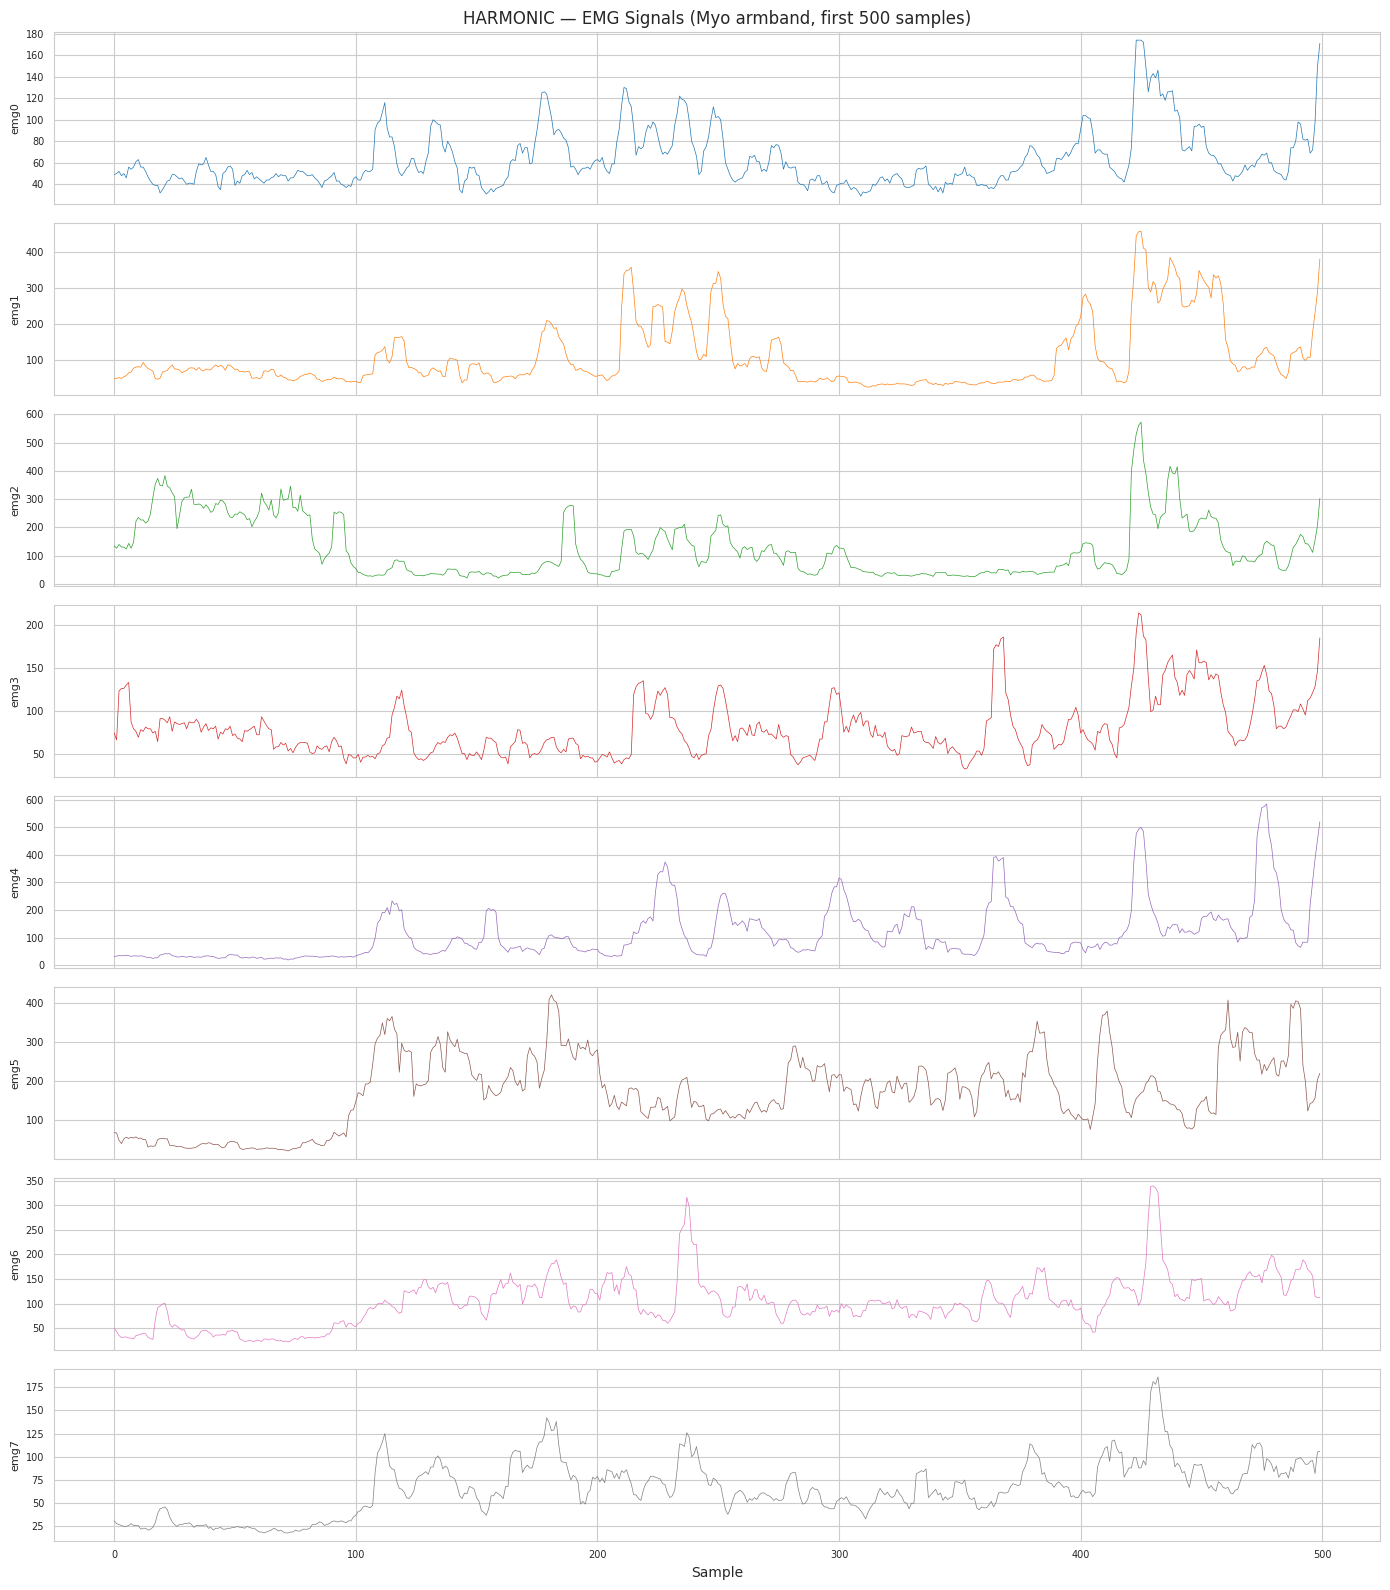

In [28]:
# ============================================================
# 3.2.1 — EMG Signal (8 channels)
# Key for: Intent recognition (Axis A1), Style modeling (Axis A2)
# ============================================================
# Note: Some trials have near-empty myo_emg.csv (~0.1 KB).
# If the current trial has no useful EMG data, we search for a
# trial that does.
# ============================================================

def find_trial_with_modality(text_dirs, modality_name, min_size_kb=1.0):
    """Find a trial directory that has a non-trivial file for a given modality."""
    for d in text_dirs:
        p = Path(d) / f'{modality_name}.csv'
        if p.exists() and p.stat().st_size / 1024 > min_size_kb:
            return Path(d)
    return None

emg_plotted = False
if TRIAL_DIR:
    # Try current trial first, then search for one with real EMG data
    emg_trial = TRIAL_DIR
    emg_path = emg_trial / 'myo_emg.csv'
    if not emg_path.exists() or emg_path.stat().st_size < 1024:
        emg_trial = find_trial_with_modality(text_data_dirs, 'myo_emg', min_size_kb=5)
        if emg_trial:
            print(f"Current trial has no EMG data. Using: {emg_trial.relative_to(HARMONIC_DIR)}")
    
    if emg_trial and (emg_trial / 'myo_emg.csv').exists() and (emg_trial / 'myo_emg.csv').stat().st_size > 1024:
        emg = pd.read_csv(emg_trial / 'myo_emg.csv')
        
        ts_cols = [c for c in emg.columns if 'timestamp' in c.lower() or 'time' in c.lower() or 'index' in c.lower()]
        emg_cols = [c for c in emg.columns if c not in ts_cols]
        
        print(f"EMG shape: {emg.shape}")
        print(f"Timestamp columns: {ts_cols}")
        print(f"EMG channels ({len(emg_cols)}): {emg_cols[:8]}")
        
        if len(emg_cols) > 0 and len(emg) > 10:
            n_ch = min(len(emg_cols), 8)
            fig, axes = plt.subplots(n_ch, 1, figsize=(14, 2 * n_ch), sharex=True)
            if n_ch == 1:
                axes = [axes]
            
            n_samples = min(500, len(emg))
            for i, col in enumerate(emg_cols[:n_ch]):
                axes[i].plot(emg[col].values[:n_samples], linewidth=0.5, color=f'C{i}')
                axes[i].set_ylabel(col, fontsize=8)
                axes[i].tick_params(labelsize=7)
            
            axes[0].set_title('HARMONIC — EMG Signals (Myo armband, first 500 samples)', fontsize=12)
            axes[-1].set_xlabel('Sample')
            plt.tight_layout()
            plt.show()
            emg_plotted = True

if not emg_plotted:
    print("EMG data not available or too small in any trial.")
    print("Modalities in current trial:", list(trial_data.keys()) if TRIAL_DIR else 'N/A')

Current trial has no IMU data. Using: harmonic_0.5.0/p100/run/003/text_data
IMU shape: (3103, 40)
IMU channels: ['orientation_x', 'orientation_y', 'orientation_z', 'orientation_w', 'orientation_covariance_0', 'orientation_covariance_1', 'orientation_covariance_2', 'orientation_covariance_3', 'orientation_covariance_4', 'orientation_covariance_5', 'orientation_covariance_6', 'orientation_covariance_7', 'orientation_covariance_8', 'angular_velocity_x', 'angular_velocity_y', 'angular_velocity_z', 'angular_covariance_0', 'angular_covariance_1', 'angular_covariance_2', 'angular_covariance_3', 'angular_covariance_4', 'angular_covariance_5', 'angular_covariance_6', 'angular_covariance_7', 'angular_covariance_8', 'linear_acceleration_x', 'linear_acceleration_y', 'linear_acceleration_z', 'linear_covariance_0', 'linear_covariance_1', 'linear_covariance_2', 'linear_covariance_3', 'linear_covariance_4', 'linear_covariance_5', 'linear_covariance_6', 'linear_covariance_7', 'linear_covariance_8']


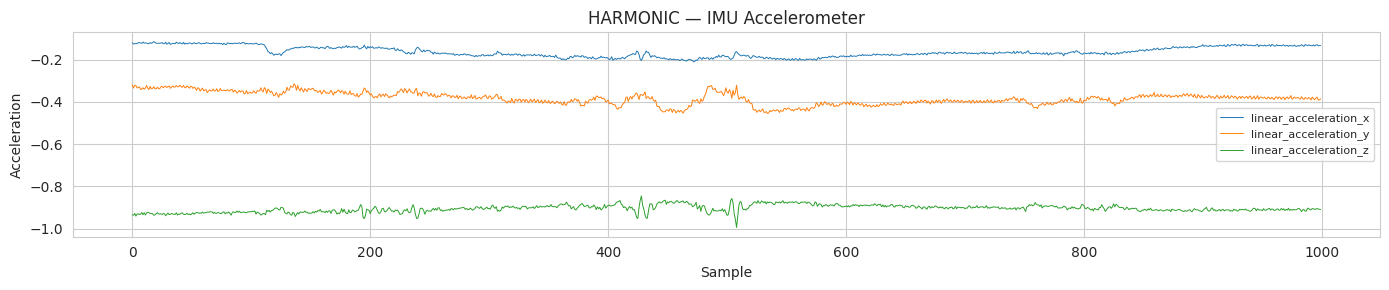

In [29]:
# ============================================================
# 3.2.2 — IMU Signal (accelerometer + gyroscope)
# Key for: Gesture detection, trajectory modeling
# ============================================================

imu_plotted = False
if TRIAL_DIR:
    imu_trial = TRIAL_DIR
    imu_path = imu_trial / 'myo_imu.csv'
    if not imu_path.exists() or imu_path.stat().st_size < 1024:
        imu_trial = find_trial_with_modality(text_data_dirs, 'myo_imu', min_size_kb=5)
        if imu_trial:
            print(f"Current trial has no IMU data. Using: {imu_trial.relative_to(HARMONIC_DIR)}")
    
    if imu_trial and (imu_trial / 'myo_imu.csv').exists() and (imu_trial / 'myo_imu.csv').stat().st_size > 1024:
        imu = pd.read_csv(imu_trial / 'myo_imu.csv')
        
        ts_cols = [c for c in imu.columns if 'timestamp' in c.lower() or 'time' in c.lower() or 'index' in c.lower()]
        imu_cols = [c for c in imu.columns if c not in ts_cols]
        
        print(f"IMU shape: {imu.shape}")
        print(f"IMU channels: {imu_cols}")
        
        if len(imu_cols) > 0 and len(imu) > 10:
            n_samples = min(1000, len(imu))
            
            # Try to identify accel vs gyro columns
            accel_cols = [c for c in imu_cols if 'acc' in c.lower() or 'accel' in c.lower()][:3]
            gyro_cols = [c for c in imu_cols if 'gyr' in c.lower() or 'gyro' in c.lower()][:3]
            
            if not accel_cols and not gyro_cols:
                # Split by position
                mid = len(imu_cols) // 2
                accel_cols = imu_cols[:mid]
                gyro_cols = imu_cols[mid:]
            
            n_plots = (1 if accel_cols else 0) + (1 if gyro_cols else 0)
            if n_plots == 0:
                n_plots = 1
                accel_cols = imu_cols  # Plot all
            
            fig, axes_arr = plt.subplots(n_plots, 1, figsize=(14, 3 * n_plots), sharex=True)
            if n_plots == 1:
                axes_arr = [axes_arr]
            
            ax_idx = 0
            if accel_cols:
                for col in accel_cols:
                    axes_arr[ax_idx].plot(imu[col].values[:n_samples], linewidth=0.7, label=col)
                axes_arr[ax_idx].set_title('HARMONIC — IMU Accelerometer', fontsize=12)
                axes_arr[ax_idx].legend(fontsize=8)
                axes_arr[ax_idx].set_ylabel('Acceleration')
                ax_idx += 1
            
            if gyro_cols and ax_idx < n_plots:
                for col in gyro_cols:
                    axes_arr[ax_idx].plot(imu[col].values[:n_samples], linewidth=0.7, label=col)
                axes_arr[ax_idx].set_title('HARMONIC — IMU Gyroscope', fontsize=12)
                axes_arr[ax_idx].legend(fontsize=8)
                axes_arr[ax_idx].set_ylabel('Angular velocity')
            
            axes_arr[-1].set_xlabel('Sample')
            plt.tight_layout()
            plt.show()
            imu_plotted = True

if not imu_plotted:
    print("IMU data not available or too small in any trial.")

Gaze shape: (4302, 22)
Gaze columns: ['timestamp', 'world_index', 'world_index_corrected', 'confidence', 'norm_pos_x', 'norm_pos_y', 'base_data', 'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z', 'eye_center0_3d_x', 'eye_center0_3d_y', 'eye_center0_3d_z', 'gaze_normal0_x', 'gaze_normal0_y', 'gaze_normal0_z', 'eye_center1_3d_x', 'eye_center1_3d_y', 'eye_center1_3d_z', 'gaze_normal1_x', 'gaze_normal1_y', 'gaze_normal1_z']
Using x=norm_pos_x, y=norm_pos_y, confidence=confidence
After confidence filter (>0.5): 4302 / 4302 samples


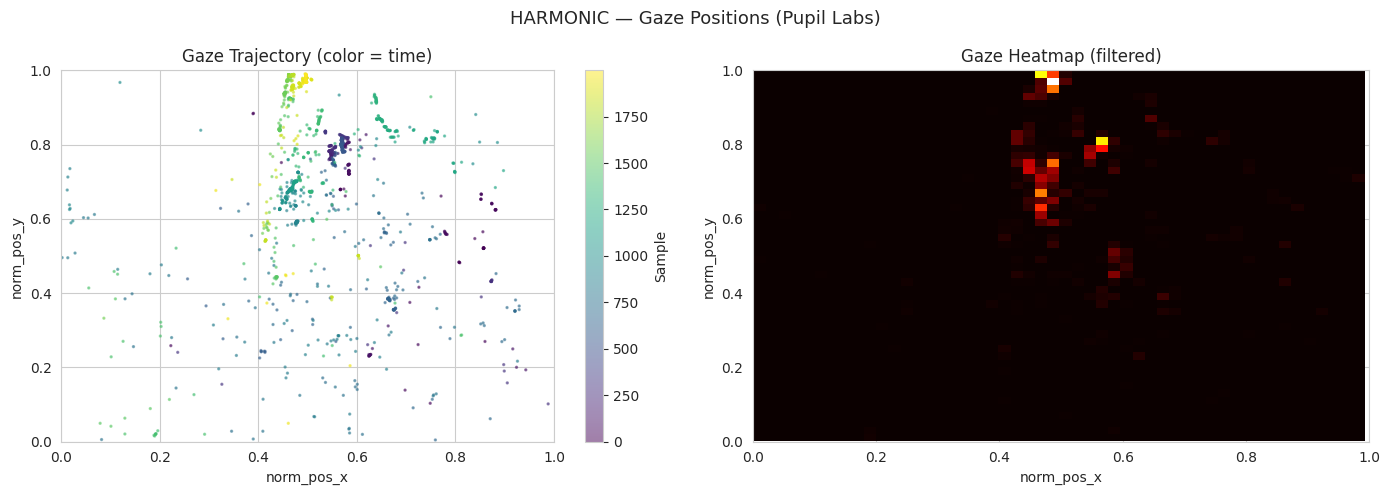

In [30]:
# ============================================================
# 3.2.3 — Gaze Positions
# Key for: Intent recognition, attention modeling
# ============================================================

if TRIAL_DIR and 'gaze_positions' in trial_data:
    gaze = trial_data['gaze_positions']
    
    print(f"Gaze shape: {gaze.shape}")
    print(f"Gaze columns: {list(gaze.columns)}")
    
    # Find position columns — use exact names first, then fallback
    x_col = None
    y_col = None
    for c in gaze.columns:
        if c == 'norm_pos_x':
            x_col = c
        if c == 'norm_pos_y':
            y_col = c
    # Fallback if exact names not found
    if x_col is None:
        candidates = [c for c in gaze.columns if 'pos_x' in c.lower() or c.lower() == 'x']
        x_col = candidates[0] if candidates else None
    if y_col is None:
        candidates = [c for c in gaze.columns if 'pos_y' in c.lower() or c.lower() == 'y']
        y_col = candidates[0] if candidates else None
    
    conf_col = None
    for c in gaze.columns:
        if 'confidence' in c.lower():
            conf_col = c
            break
    
    print(f"Using x={x_col}, y={y_col}, confidence={conf_col}")
    
    if x_col and y_col:
        # Filter by confidence if available
        gaze_clean = gaze.copy()
        if conf_col:
            gaze_clean = gaze_clean[gaze_clean[conf_col] > 0.5]
            print(f"After confidence filter (>0.5): {len(gaze_clean)} / {len(gaze)} samples")
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Gaze trajectory (color = time)
        n = min(2000, len(gaze_clean))
        scatter = ax1.scatter(gaze_clean[x_col].values[:n], gaze_clean[y_col].values[:n], 
                   c=range(n), cmap='viridis', s=2, alpha=0.5)
        ax1.set_xlabel(x_col)
        ax1.set_ylabel(y_col)
        ax1.set_title('Gaze Trajectory (color = time)')
        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)
        plt.colorbar(scatter, ax=ax1, label='Sample')
        
        # Gaze heatmap
        x_vals = gaze_clean[x_col].dropna().values
        y_vals = gaze_clean[y_col].dropna().values
        # Clip to valid range
        mask = (x_vals >= 0) & (x_vals <= 1) & (y_vals >= 0) & (y_vals <= 1)
        ax2.hist2d(x_vals[mask], y_vals[mask], bins=50, cmap='hot')
        ax2.set_xlabel(x_col)
        ax2.set_ylabel(y_col)
        ax2.set_title('Gaze Heatmap (filtered)')
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        
        plt.suptitle('HARMONIC — Gaze Positions (Pupil Labs)', fontsize=13)
        plt.tight_layout()
        plt.show()
    else:
        print("Could not identify gaze position columns.")
else:
    print("Gaze data not available.")

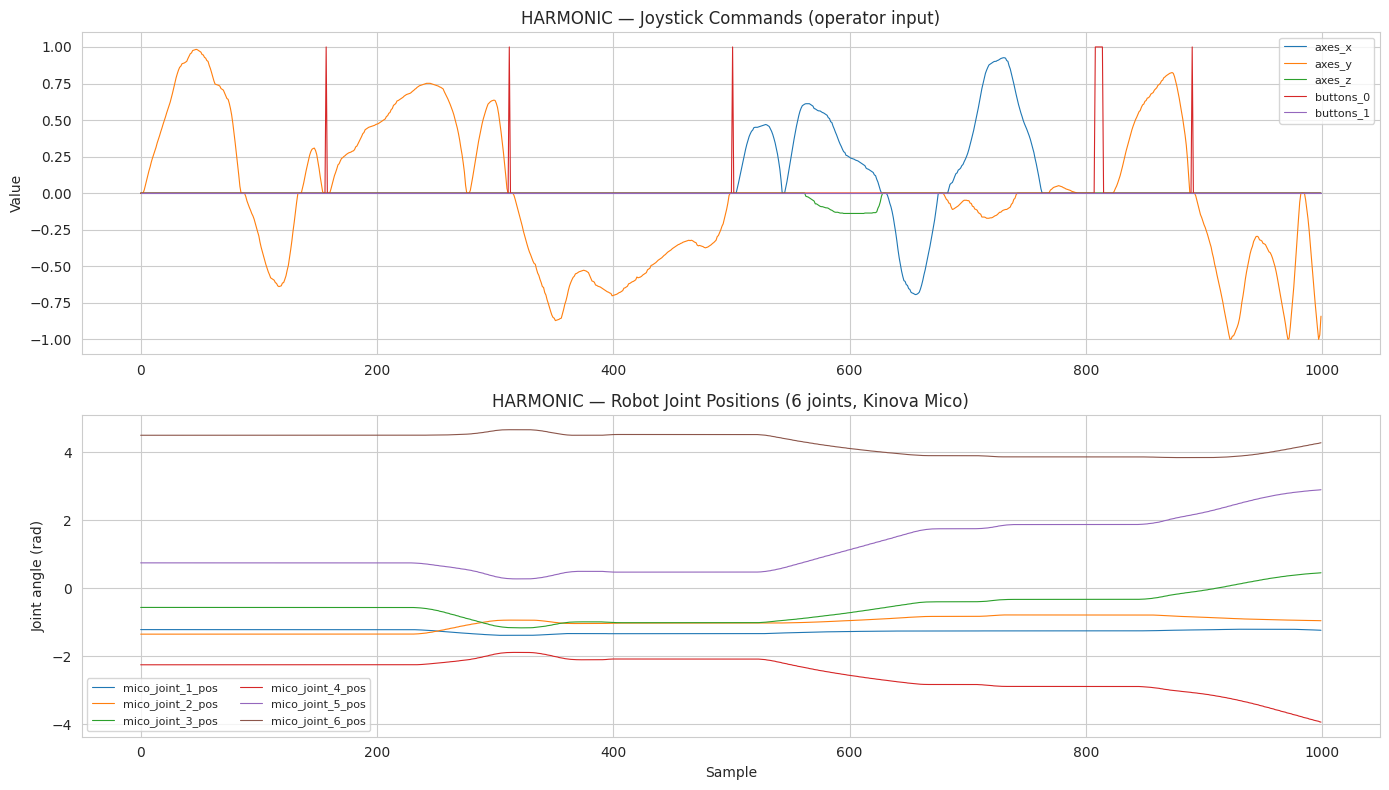

In [31]:
# ============================================================
# 3.2.4 — Joystick Input + Robot Joint Positions
# Key for: IRL (operator commands → reward inference)
# ============================================================
# Note: HARMONIC uses "joint_positions" (not "joint_states")
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Joystick
if TRIAL_DIR and 'ada_joy' in trial_data:
    joy = trial_data['ada_joy']
    ts_cols = [c for c in joy.columns if 'timestamp' in c.lower() or 'index' in c.lower()]
    joy_cols = [c for c in joy.columns if c not in ts_cols]
    
    n = min(1000, len(joy))
    for col in joy_cols:
        axes[0].plot(joy[col].values[:n], linewidth=0.8, label=col)
    axes[0].set_title('HARMONIC — Joystick Commands (operator input)', fontsize=12)
    axes[0].legend(fontsize=8)
    axes[0].set_ylabel('Value')
else:
    axes[0].text(0.5, 0.5, 'Joystick data not available in this trial', 
                transform=axes[0].transAxes, ha='center', fontsize=12, color='gray')

# Robot joint positions (file is "joint_positions.csv", key is "joint_positions")
joint_key = None
for k in ['joint_positions', 'joint_states']:
    if TRIAL_DIR and k in trial_data:
        joint_key = k
        break

if joint_key:
    joints = trial_data[joint_key]
    ts_cols = [c for c in joints.columns if 'timestamp' in c.lower() or 'index' in c.lower()]
    joint_cols = [c for c in joints.columns if c not in ts_cols]
    
    # Show up to 6 DOF
    plot_cols = joint_cols[:6]
    n = min(1000, len(joints))
    for col in plot_cols:
        axes[1].plot(joints[col].values[:n], linewidth=0.8, label=col)
    axes[1].set_title(f'HARMONIC — Robot Joint Positions ({len(plot_cols)} joints, Kinova Mico)', fontsize=12)
    axes[1].legend(fontsize=8, ncol=2)
    axes[1].set_ylabel('Joint angle (rad)')
    axes[1].set_xlabel('Sample')
else:
    axes[1].text(0.5, 0.5, 'Joint position data not available in this trial', 
                transform=axes[1].transAxes, ha='center', fontsize=12, color='gray')

plt.tight_layout()
plt.show()

Robot position shape: (6202, 30)
Columns: ['timestamp', 'world_index', 'world_index_corrected', 'mico_link_base_x', 'mico_link_base_y', 'mico_link_base_z', 'mico_link_1_x', 'mico_link_1_y', 'mico_link_1_z', 'mico_link_2_x', 'mico_link_2_y', 'mico_link_2_z', 'mico_link_3_x', 'mico_link_3_y', 'mico_link_3_z', 'mico_link_4_x', 'mico_link_4_y', 'mico_link_4_z', 'mico_link_5_x', 'mico_link_5_y', 'mico_link_5_z', 'mico_link_hand_x', 'mico_link_hand_y', 'mico_link_hand_z', 'mico_end_effector_x', 'mico_end_effector_y', 'mico_end_effector_z', 'mico_fork_tip_x', 'mico_fork_tip_y', 'mico_fork_tip_z']

Plotting: mico_end_effector_x, mico_end_effector_y, mico_end_effector_z
  X range: [0.0415, 0.2601]
  Y range: [-0.4177, -0.2830]
  Z range: [0.1147, 0.3577]


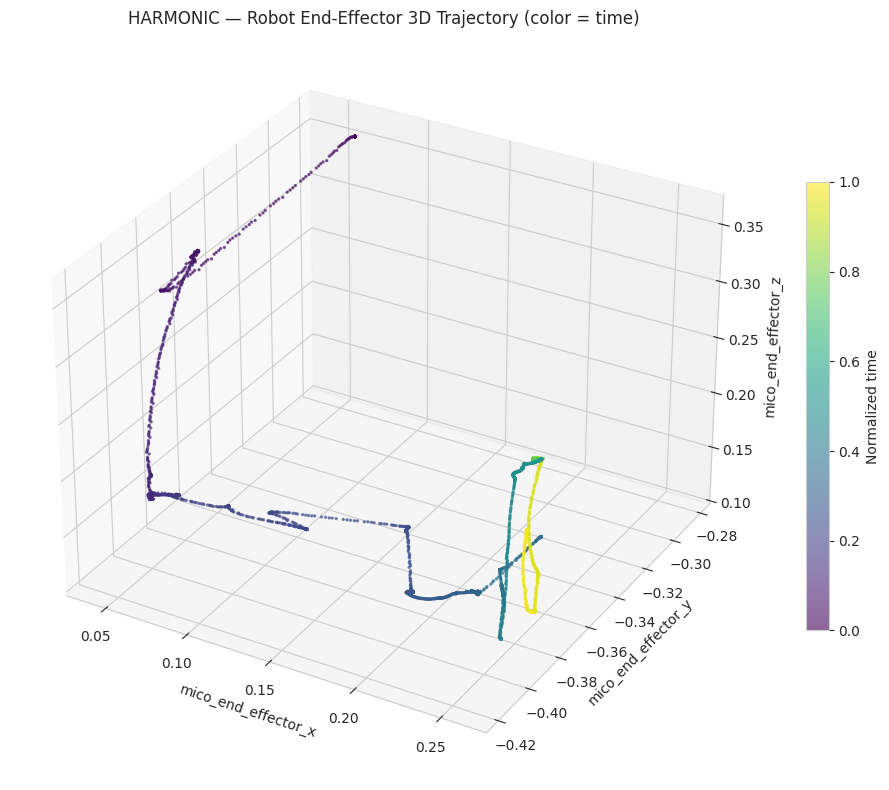

In [49]:
# ============================================================
# 3.2.5 — Robot End-Effector Position (3D trajectory)
# Key for: Behavior generation (Axis A3)
# ============================================================

if TRIAL_DIR and 'robot_position' in trial_data:
    rpos = trial_data['robot_position']
    print(f"Robot position shape: {rpos.shape}")
    print(f"Columns: {list(rpos.columns)}")
    
    # Prefer actual end-effector columns (mico_end_effector_x/y/z)
    ee_x = [c for c in rpos.columns if 'end_effector' in c.lower() and c.endswith('_x')]
    ee_y = [c for c in rpos.columns if 'end_effector' in c.lower() and c.endswith('_y')]
    ee_z = [c for c in rpos.columns if 'end_effector' in c.lower() and c.endswith('_z')]
    
    if ee_x and ee_y and ee_z:
        x_col, y_col, z_col = ee_x[0], ee_y[0], ee_z[0]
    else:
        # Fallback: skip timestamp/index columns and try hand or last 3 numeric columns
        pos_cols = [c for c in rpos.columns 
                    if 'timestamp' not in c.lower() and 'index' not in c.lower()]
        # Prefer hand link if no end-effector
        hand_cols = [c for c in pos_cols if 'hand' in c.lower()]
        if len(hand_cols) >= 3:
            x_col, y_col, z_col = hand_cols[0], hand_cols[1], hand_cols[2]
        elif len(pos_cols) >= 3:
            # Use last 3 columns (typically the most distal link)
            x_col, y_col, z_col = pos_cols[-3], pos_cols[-2], pos_cols[-1]
        else:
            x_col = y_col = z_col = None
    
    if x_col and y_col and z_col:
        x = rpos[x_col].values
        y = rpos[y_col].values
        z = rpos[z_col].values
        
        print(f"\nPlotting: {x_col}, {y_col}, {z_col}")
        print(f"  X range: [{x.min():.4f}, {x.max():.4f}]")
        print(f"  Y range: [{y.min():.4f}, {y.max():.4f}]")
        print(f"  Z range: [{z.min():.4f}, {z.max():.4f}]")
        
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        colors = np.linspace(0, 1, len(x))
        sc = ax.scatter(x, y, z, c=colors, cmap='viridis', s=2, alpha=0.6)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_zlabel(z_col)
        ax.set_title('HARMONIC — Robot End-Effector 3D Trajectory (color = time)')
        plt.colorbar(sc, ax=ax, label='Normalized time', shrink=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("Could not identify 3 position columns for end-effector.")
else:
    print("Robot position data not available.")

## 3.3 — HARMONIC: Cross-Participant Statistics

Compute statistics across participants to understand inter-subject variability (key for style modeling).

In [33]:
# ============================================================
# Load summary statistics across all participants
# ============================================================
# Only use "run" trials (full multimodal), skip "check" (calibration only)
# ============================================================

def get_trial_stats(text_data_dir):
    """Compute basic statistics for a single HARMONIC trial."""
    stats = {'trial_path': str(text_data_dir)}
    parts = str(text_data_dir).split('/')
    
    # Extract participant ID from path
    for p in parts:
        if p.startswith('p') and p[1:].isdigit():
            stats['participant'] = p
            break
    
    # Extract trial type (run/check)
    if '/run/' in str(text_data_dir):
        stats['trial_type'] = 'run'
    elif '/check/' in str(text_data_dir):
        stats['trial_type'] = 'check'
    
    td = Path(text_data_dir)
    
    # EMG stats
    emg_path = td / 'myo_emg.csv'
    if emg_path.exists() and emg_path.stat().st_size > 100:
        try:
            emg = pd.read_csv(emg_path)
            ts_cols = [c for c in emg.columns if 'timestamp' in c.lower() or 'index' in c.lower()]
            emg_cols = [c for c in emg.columns if c not in ts_cols]
            if len(emg) > 0 and emg_cols:
                stats['emg_samples'] = len(emg)
                stats['emg_mean'] = emg[emg_cols].mean().mean()
                stats['emg_std'] = emg[emg_cols].std().mean()
        except Exception:
            pass
    
    # Joystick stats
    joy_path = td / 'ada_joy.csv'
    if joy_path.exists() and joy_path.stat().st_size > 100:
        try:
            joy = pd.read_csv(joy_path)
            stats['joy_samples'] = len(joy)
        except Exception:
            pass
    
    # Joint positions (not "joint_states")
    for jf in ['joint_positions.csv', 'joint_states.csv']:
        joints_path = td / jf
        if joints_path.exists() and joints_path.stat().st_size > 100:
            try:
                joints = pd.read_csv(joints_path)
                stats['joint_samples'] = len(joints)
            except Exception:
                pass
            break
    
    # Gaze
    gaze_path = td / 'gaze_positions.csv'
    if gaze_path.exists() and gaze_path.stat().st_size > 100:
        try:
            gaze = pd.read_csv(gaze_path)
            stats['gaze_samples'] = len(gaze)
        except Exception:
            pass
    
    return stats

if text_data_dirs:
    print(f"Computing statistics for {len(text_data_dirs)} trials (run only)...")
    all_stats = []
    for td in tqdm(text_data_dirs):
        try:
            all_stats.append(get_trial_stats(td))
        except Exception as e:
            print(f"Error on {td}: {e}")
    
    stats_df = pd.DataFrame(all_stats)
    print(f"\nSummary ({len(stats_df)} trials):")
    display(stats_df.describe())
    
    # Trials per participant
    if 'participant' in stats_df.columns:
        print("\nTrials per participant:")
        print(stats_df['participant'].value_counts().sort_index())
    
    # Show modality availability
    for col in ['emg_samples', 'joy_samples', 'joint_samples', 'gaze_samples']:
        if col in stats_df.columns:
            avail = stats_df[col].notna().sum()
            print(f"  {col.replace('_samples',''):>10}: {avail}/{len(stats_df)} trials have data")
else:
    print("No trials found.")

Computing statistics for 447 trials (run only)...


  0%|          | 0/447 [00:00<?, ?it/s]


Summary (447 trials):


,joy_samples,joint_samples,gaze_samples,emg_samples,emg_mean,emg_std
count,447.000000,447.000000,447.000000,96.000000,96.000000,96.000000
mean,1758.257271,3737.803132,7358.369128,2213.177083,106.760150,67.676861
std,1586.170527,2409.841117,5393.760330,1634.019629,24.536965,16.847597
min,2.000000,990.000000,579.000000,711.000000,54.053929,31.499835
25%,817.500000,2149.000000,4036.000000,1197.250000,90.192115,56.870009
50%,1298.000000,2985.000000,5811.000000,1714.000000,108.368761,64.887199
75%,2140.000000,4559.500000,8960.500000,2536.250000,124.641996,76.550094
max,12435.000000,17900.000000,40763.000000,10816.000000,181.865046,108.824214



Trials per participant:
participant
p100    19
p101    20
p102    20
p103    20
p104    14
p105    10
p106    19
p107    17
p108    14
p109    20
p110    20
p111    20
p112    20
p113    19
p114    20
p115    20
p116    19
p117    16
p118    20
p119    20
p120    20
p121    20
p122    20
p123    20
Name: count, dtype: int64
         emg: 96/447 trials have data
         joy: 447/447 trials have data
       joint: 447/447 trials have data
        gaze: 447/447 trials have data


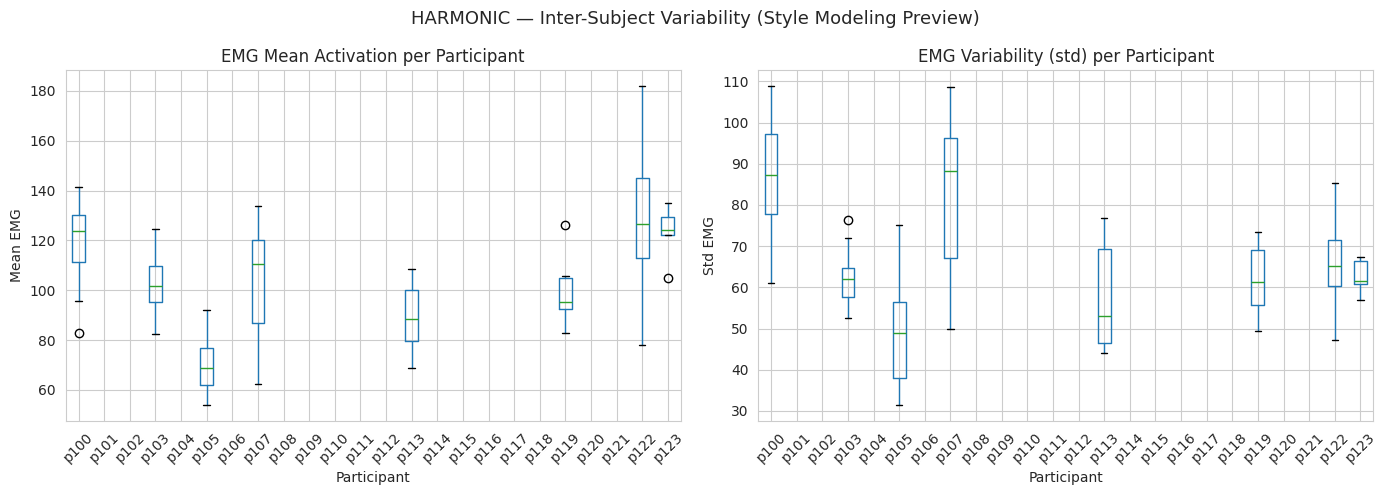

In [34]:
# ============================================================
# Visualize inter-subject EMG variability
# This is a preview of what style modeling (Axis A1) will capture
# ============================================================

if text_data_dirs and 'participant' in stats_df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    if 'emg_mean' in stats_df.columns:
        stats_df.boxplot(column='emg_mean', by='participant', ax=ax1, rot=45)
        ax1.set_title('EMG Mean Activation per Participant')
        ax1.set_xlabel('Participant')
        ax1.set_ylabel('Mean EMG')
    
    if 'emg_std' in stats_df.columns:
        stats_df.boxplot(column='emg_std', by='participant', ax=ax2, rot=45)
        ax2.set_title('EMG Variability (std) per Participant')
        ax2.set_xlabel('Participant')
        ax2.set_ylabel('Std EMG')
    
    plt.suptitle('HARMONIC — Inter-Subject Variability (Style Modeling Preview)', fontsize=13)
    plt.tight_layout()
    plt.show()

---
# Part 4 — Explore DASIG Data

## 4.1 — Load subject info and inspect MIMU structure

In [35]:
# ============================================================
# 4.1.1 — Load subjects info (anthropometric data)
# ============================================================
# DASIG CSVs use ';' as separator and ',' as decimal point.
# subjects_info.csv also has BOM encoding.
# ============================================================

subjects_info_path = list(DASIG_DIR.rglob('subjects_info.csv'))
print(f"Found subjects_info files: {subjects_info_path}")

if subjects_info_path:
    subjects_info = pd.read_csv(subjects_info_path[0], sep=';', decimal=',', encoding='utf-8-sig')
    print(f"\nSubjects info shape: {subjects_info.shape}")
    print(f"Columns: {list(subjects_info.columns)}")
    display(subjects_info.head(10))
    print(f"\nBasic statistics:")
    display(subjects_info.describe())
else:
    print("subjects_info.csv not found")
    subjects_info = None

Found subjects_info files: [PosixPath('/content/data/dasig/DASIG/subjects_info.csv')]

Subjects info shape: (60, 10)
Columns: ['Subject', 'Gender', 'Age range (years)', 'Height (m)', 'Weight (kg)', 'Dominant arm', 'Right upper arm length (m)', 'Left upper arm length (m)', 'Right forearm length (m)', 'Left forearm length (m)']


,Subject,Gender,Age range (years),Height (m),Weight (kg),Dominant arm,Right upper arm length (m),Left upper arm length (m),Right forearm length (m),Left forearm length (m)
0,sub001,female,20-24,1.69,65,right,0.33,0.33,0.27,0.28
1,sub002,male,25-29,1.75,63,right,0.32,0.32,0.27,0.28
2,sub003,male,20-24,1.88,92,left,0.32,0.31,0.31,0.32
3,sub004,male,25-29,1.68,55,right,0.28,0.28,0.24,0.25
4,sub005,female,20-24,1.67,64,right,0.31,0.30,0.29,0.28
5,sub006,female,25-29,1.70,54,right,0.29,0.30,0.27,0.27
6,sub007,female,25-29,1.66,54,right,0.30,0.29,0.26,0.27
7,sub008,female,25-29,1.61,61,right,0.29,0.29,0.25,0.25
8,sub009,male,25-29,1.85,71,right,0.35,0.35,0.30,0.29
9,sub010,male,25-29,1.82,86,right,0.35,0.34,0.30,0.30



Basic statistics:


,Height (m),Weight (kg),Right upper arm length (m),Left upper arm length (m),Right forearm length (m),Left forearm length (m)
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1.731833,67.933333,0.341833,0.341333,0.291667,0.292000
std,0.085162,11.158134,0.027153,0.026774,0.023446,0.022459
min,1.500000,50.000000,0.280000,0.280000,0.240000,0.250000
25%,1.667500,60.000000,0.320000,0.320000,0.270000,0.280000
50%,1.740000,65.000000,0.340000,0.340000,0.290000,0.290000
75%,1.800000,75.000000,0.360000,0.360000,0.310000,0.302500
max,1.880000,97.000000,0.400000,0.400000,0.360000,0.360000


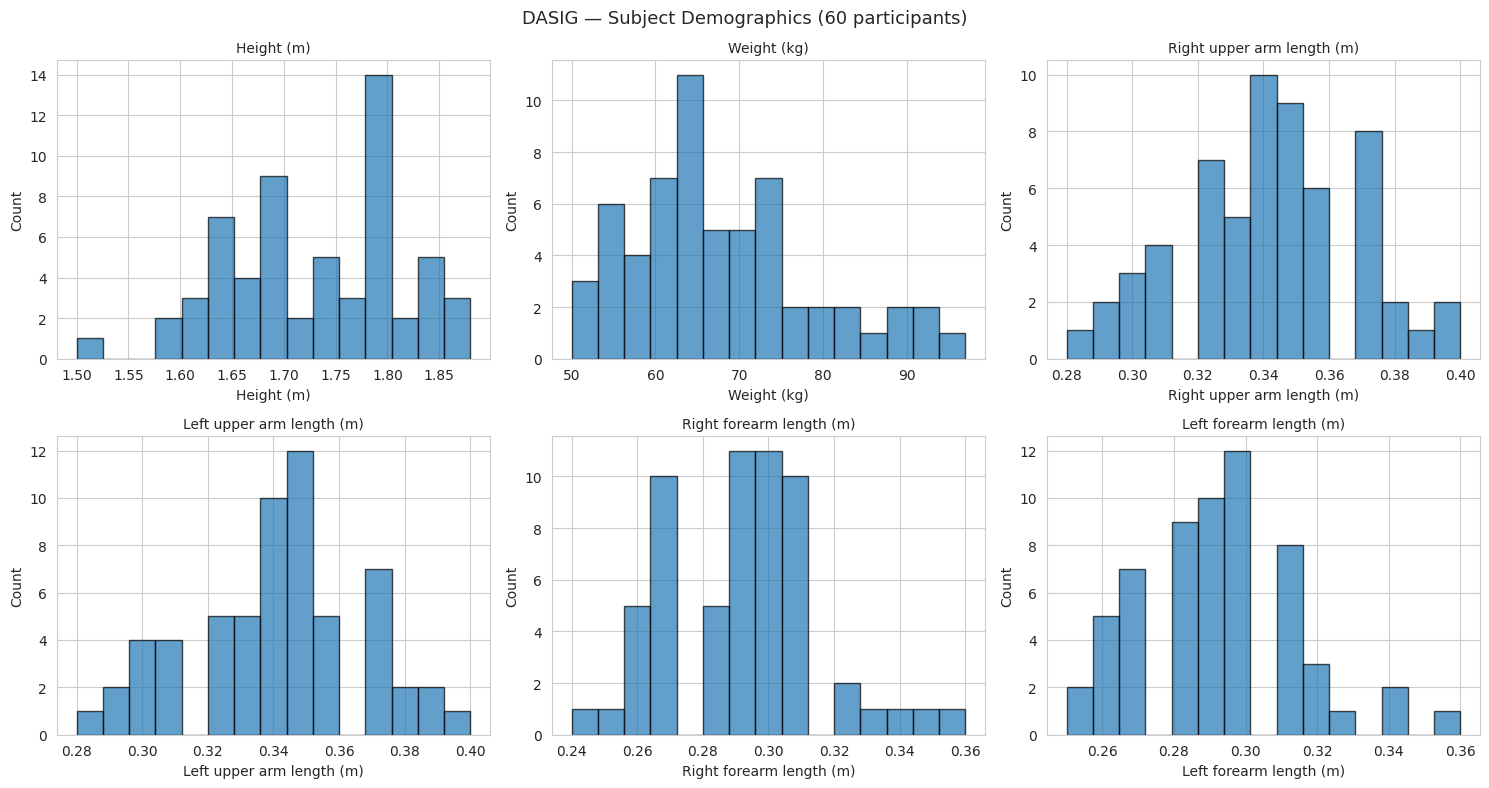

In [36]:
# ============================================================
# 4.1.2 — Visualize subject demographics
# ============================================================

if subjects_info is not None and len(subjects_info) > 0:
    num_cols = subjects_info.select_dtypes(include=[np.number]).columns.tolist()
    n_plots = min(len(num_cols), 6)
    
    if n_plots > 0:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.flatten()
        
        for i, col in enumerate(num_cols[:n_plots]):
            subjects_info[col].hist(ax=axes[i], bins=15, edgecolor='black', alpha=0.7)
            axes[i].set_title(col, fontsize=10)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Count')
        
        # Hide unused axes
        for i in range(n_plots, len(axes)):
            axes[i].set_visible(False)
        
        plt.suptitle('DASIG — Subject Demographics (60 participants)', fontsize=13)
        plt.tight_layout()
        plt.show()

In [37]:
# ============================================================
# 4.1.3 — Load one subject's MIMU data
# ============================================================
# DASIG MIMU files have 3 header rows:
#   Row 0: Body segment names (Right Forearm, Left Forearm, Sternum, ...)
#   Row 1: Sensor types (Accelerometer, Gyroscope, Magnetometer, Orientation)
#   Row 2: Axis labels (X, Y, Z, S)
#   Row 3+: Data (using ';' separator and ',' decimal)
#
# Structure: 5 body segments × 13 channels each + 1 time column = 66 columns
#   Per segment: Acc(X,Y,Z), Gyro(X,Y,Z), Mag(X,Y,Z), Ori(S,X,Y,Z) = 13
# ============================================================

# Build clean column names
_segments = ['RF', 'LF', 'ST', 'RUA', 'LUA']  # Right Forearm, Left Forearm, Sternum, Right/Left Upper Arm
_sensors = [
    ('Acc', ['X', 'Y', 'Z']),
    ('Gyro', ['X', 'Y', 'Z']),
    ('Mag', ['X', 'Y', 'Z']),
    ('Ori', ['S', 'X', 'Y', 'Z']),
]
MIMU_COLUMNS = ['Time_s']
for seg in _segments:
    for sensor_name, axes in _sensors:
        for axis in axes:
            MIMU_COLUMNS.append(f'{seg}_{sensor_name}_{axis}')

print(f"Expected MIMU columns: {len(MIMU_COLUMNS)} (Time + 5 segments × 13 channels)")

def load_mimu(path):
    """Load a DASIG MIMU CSV with proper parsing."""
    df = pd.read_csv(path, sep=';', decimal=',', skiprows=3, header=None)
    if df.shape[1] == len(MIMU_COLUMNS):
        df.columns = MIMU_COLUMNS
    else:
        print(f"  Warning: expected {len(MIMU_COLUMNS)} cols, got {df.shape[1]}")
    return df

# Find all MIMU files
mimu_files = sorted(DASIG_DIR.rglob('*_MIMU.csv'))
print(f"\nFound {len(mimu_files)} MIMU files")

mimu_sample = None
if mimu_files:
    for f in mimu_files[:6]:
        print(f"  {f.name:40s}  {f.stat().st_size / 1024:.1f} KB")
    if len(mimu_files) > 6:
        print(f"  ... and {len(mimu_files) - 6} more")
    
    # Load first MIMU file
    print(f"\nLoading: {mimu_files[0].name}")
    mimu_sample = load_mimu(mimu_files[0])
    print(f"Shape: {mimu_sample.shape}")
    print(f"Columns: {list(mimu_sample.columns)}")
    print(f"\nFirst 5 rows:")
    display(mimu_sample.head())
    print(f"\nStatistics:")
    display(mimu_sample.describe())
else:
    print("No MIMU files found.")

Expected MIMU columns: 66 (Time + 5 segments × 13 channels)

Found 180 MIMU files
  sub001_FR_L_MIMU.csv                      11966.2 KB
  sub001_FR_R_MIMU.csv                      11960.2 KB
  sub001_LA_L_MIMU.csv                      11901.1 KB
  sub002_FR_L_MIMU.csv                      11928.5 KB
  sub002_FR_R_MIMU.csv                      11887.3 KB
  sub002_LA_L_MIMU.csv                      11906.0 KB
  ... and 174 more

Loading: sub001_FR_L_MIMU.csv
Shape: (19385, 66)
Columns: ['Time_s', 'RF_Acc_X', 'RF_Acc_Y', 'RF_Acc_Z', 'RF_Gyro_X', 'RF_Gyro_Y', 'RF_Gyro_Z', 'RF_Mag_X', 'RF_Mag_Y', 'RF_Mag_Z', 'RF_Ori_S', 'RF_Ori_X', 'RF_Ori_Y', 'RF_Ori_Z', 'LF_Acc_X', 'LF_Acc_Y', 'LF_Acc_Z', 'LF_Gyro_X', 'LF_Gyro_Y', 'LF_Gyro_Z', 'LF_Mag_X', 'LF_Mag_Y', 'LF_Mag_Z', 'LF_Ori_S', 'LF_Ori_X', 'LF_Ori_Y', 'LF_Ori_Z', 'ST_Acc_X', 'ST_Acc_Y', 'ST_Acc_Z', 'ST_Gyro_X', 'ST_Gyro_Y', 'ST_Gyro_Z', 'ST_Mag_X', 'ST_Mag_Y', 'ST_Mag_Z', 'ST_Ori_S', 'ST_Ori_X', 'ST_Ori_Y', 'ST_Ori_Z', 'RUA_Acc_X', 'RUA_Acc_

,Time_s,RF_Acc_X,RF_Acc_Y,RF_Acc_Z,RF_Gyro_X,RF_Gyro_Y,RF_Gyro_Z,RF_Mag_X,RF_Mag_Y,RF_Mag_Z,...,LUA_Gyro_X,LUA_Gyro_Y,LUA_Gyro_Z,LUA_Mag_X,LUA_Mag_Y,LUA_Mag_Z,LUA_Ori_S,LUA_Ori_X,LUA_Ori_Y,LUA_Ori_Z
0,0.000,7.199324,-5.905339,3.140357,0.098804,0.031510,-0.004273,-25.183893,46.845934,-18.848230,...,0.060223,0.040641,-0.029095,51.820427,23.438215,-21.185060,-0.065636,-0.624852,-0.277319,0.726875
1,0.005,7.208467,-5.887023,3.146456,0.095867,0.032845,-0.002671,-25.141152,46.906923,-18.930609,...,0.057222,0.044252,-0.029908,51.909375,23.428331,-21.143223,-0.065501,-0.624904,-0.277253,0.726867
2,0.010,7.205422,-5.883968,3.149510,0.091862,0.033913,-0.001335,-25.208268,47.028997,-18.958097,...,0.057477,0.048321,-0.033367,51.930294,23.426006,-21.232171,-0.065357,-0.624962,-0.277193,0.726853
3,0.015,7.211521,-5.856509,3.131204,0.085987,0.034181,-0.001068,-25.232702,47.059540,-19.040476,...,0.061139,0.050000,-0.034181,52.276202,23.396358,-21.332154,-0.065204,-0.625023,-0.277127,0.726840
4,0.020,7.214575,-5.874806,3.152555,0.077977,0.033380,-0.001869,-25.223549,47.068693,-19.150341,...,0.063682,0.049338,-0.033316,51.922695,23.428918,-21.271684,-0.065049,-0.625083,-0.277055,0.726829



Statistics:


,Time_s,RF_Acc_X,RF_Acc_Y,RF_Acc_Z,RF_Gyro_X,RF_Gyro_Y,RF_Gyro_Z,RF_Mag_X,RF_Mag_Y,RF_Mag_Z,...,LUA_Gyro_X,LUA_Gyro_Y,LUA_Gyro_Z,LUA_Mag_X,LUA_Mag_Y,LUA_Mag_Z,LUA_Ori_S,LUA_Ori_X,LUA_Ori_Y,LUA_Ori_Z
count,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,...,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000,19385.000000
mean,48.460000,6.906706,-6.023934,3.446548,0.008987,-0.007069,0.003142,-22.393719,45.962478,-18.206218,...,0.020288,0.013214,0.020843,28.131016,34.583510,-33.987175,0.253161,-0.483891,-0.318011,0.717742
std,27.980559,0.431922,0.625866,0.793999,0.243289,0.118197,0.104612,2.599593,1.609377,4.910971,...,0.812921,0.995415,1.092994,14.660184,8.262674,6.504911,0.232158,0.102740,0.089968,0.113717
min,0.000000,-3.898711,-34.345145,-14.547318,-2.897788,-4.481915,-5.366942,-32.894186,34.691182,-31.575956,...,-7.250652,-4.119460,-5.231788,-45.224028,-1.220281,-54.947642,-0.226667,-0.676345,-0.696062,0.315551
25%,24.230000,6.659309,-6.299391,3.104137,-0.123382,-0.047521,-0.033626,-23.878379,45.426369,-21.324920,...,-0.357804,-0.295877,-0.387317,21.630478,29.295648,-38.482947,0.057712,-0.536637,-0.378549,0.640202
50%,48.460000,6.881792,-6.070241,3.567665,-0.009582,-0.001637,0.003997,-22.341892,46.062508,-18.564361,...,0.026995,0.043407,0.013228,30.084627,35.286559,-34.686178,0.196008,-0.493104,-0.315776,0.755392
75%,72.690000,7.116916,-5.801595,3.930784,0.115061,0.041886,0.039755,-20.828965,46.752302,-15.820795,...,0.395946,0.527810,0.526315,36.514052,40.799194,-29.891317,0.474924,-0.444280,-0.261083,0.806636
max,96.920000,18.154135,15.015644,20.528604,4.652472,3.354875,1.802773,-12.120075,50.761355,-2.968782,...,5.038566,4.387766,4.282700,56.616486,58.375973,-8.584009,0.745765,0.112691,-0.043600,0.928574


In [38]:
# ============================================================
# 4.1.4 — Load corresponding Arduino (alarm) data
# ============================================================
# Format: ';' separated, ',' decimal. Columns: Time (s), Stimuli
# ============================================================

arduino_files = sorted(DASIG_DIR.rglob('*_Arduino.csv'))
print(f"Found {len(arduino_files)} Arduino alarm files")

alarm_sample = None
if arduino_files:
    print(f"\nLoading: {arduino_files[0].name}")
    alarm_sample = pd.read_csv(arduino_files[0], sep=';', decimal=',')
    print(f"Shape: {alarm_sample.shape}")
    print(f"Columns: {list(alarm_sample.columns)}")
    print(f"\nContent (alarm timestamps and stimuli codes):")
    display(alarm_sample)
else:
    print("No Arduino files found.")

Found 180 Arduino alarm files

Loading: sub001_FR_L_Arduino.csv
Shape: (35, 2)
Columns: ['Time (s)', 'Stimuli']

Content (alarm timestamps and stimuli codes):


,Time (s),Stimuli
0,0.000,0
1,2.001,2
2,5.001,3
3,8.001,4
4,11.002,5
5,14.002,2
6,17.002,3
7,20.003,4
8,23.003,5
9,26.003,2


## 4.2 — Visualize DASIG MIMU Signals

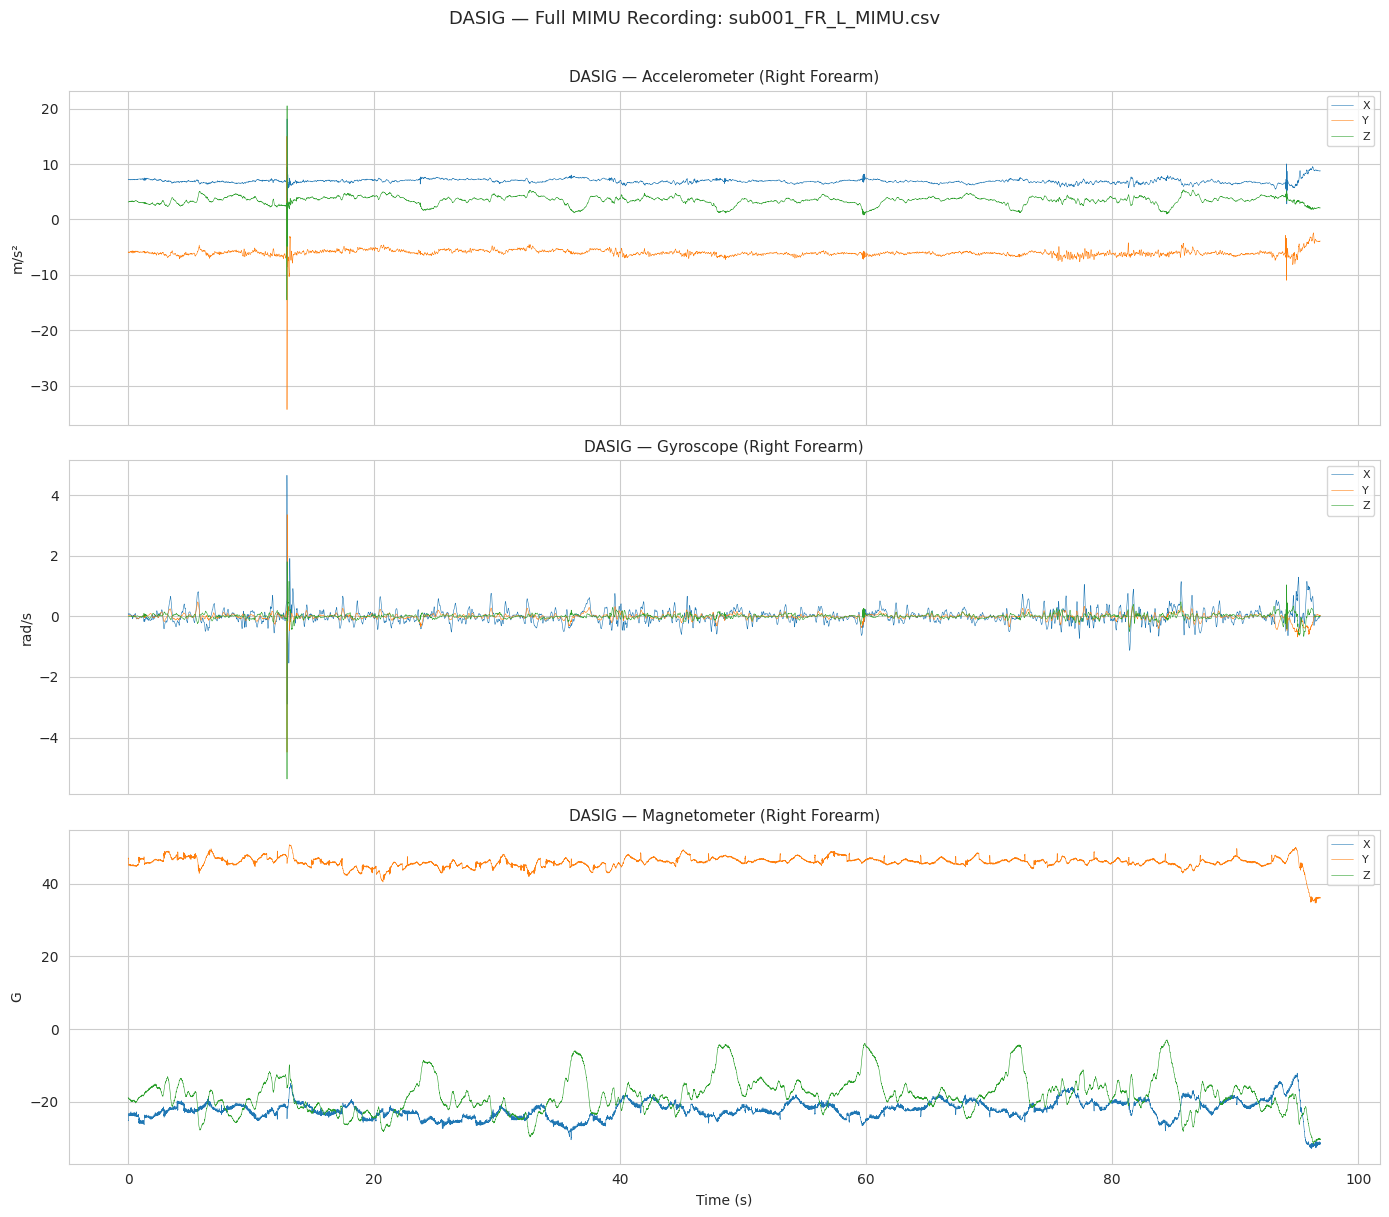


Recording duration: 96.9s (19385 samples)
Sampling rate: ~200 Hz


In [39]:
# ============================================================
# 4.2.1 — Plot full MIMU recording for one subject
# Using Right Forearm segment: Accelerometer, Gyroscope, Magnetometer
# ============================================================

if mimu_sample is not None and len(mimu_sample) > 0:
    # Use Right Forearm (RF) channels for visualization
    accel_cols = ['RF_Acc_X', 'RF_Acc_Y', 'RF_Acc_Z']
    gyro_cols = ['RF_Gyro_X', 'RF_Gyro_Y', 'RF_Gyro_Z']
    mag_cols = ['RF_Mag_X', 'RF_Mag_Y', 'RF_Mag_Z']
    
    # Verify columns exist (fallback to any available)
    if not all(c in mimu_sample.columns for c in accel_cols):
        numeric_cols = mimu_sample.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c != 'Time_s']
        accel_cols = numeric_cols[0:3] if len(numeric_cols) >= 3 else numeric_cols
        gyro_cols = numeric_cols[3:6] if len(numeric_cols) >= 6 else []
        mag_cols = numeric_cols[6:9] if len(numeric_cols) >= 9 else []
    
    time_col = 'Time_s' if 'Time_s' in mimu_sample.columns else None
    x_data = mimu_sample[time_col].values if time_col else np.arange(len(mimu_sample))
    x_label = 'Time (s)' if time_col else 'Sample'
    
    sensor_groups = [
        ('Accelerometer (Right Forearm)', accel_cols, 'm/s²'),
        ('Gyroscope (Right Forearm)', gyro_cols, 'rad/s'),
        ('Magnetometer (Right Forearm)', mag_cols, 'G'),
    ]
    
    n_groups = sum(1 for _, cols, _ in sensor_groups if cols)
    fig, axes = plt.subplots(n_groups, 1, figsize=(14, 4 * n_groups), sharex=True)
    if n_groups == 1:
        axes = [axes]
    
    ax_idx = 0
    for name, group_cols, unit in sensor_groups:
        if group_cols:
            for col in group_cols:
                if col in mimu_sample.columns:
                    label = col.split('_')[-1] if '_' in col else col  # Just show axis (X/Y/Z)
                    axes[ax_idx].plot(x_data, mimu_sample[col].values, linewidth=0.4, label=label)
            axes[ax_idx].set_title(f'DASIG — {name}', fontsize=11)
            axes[ax_idx].set_ylabel(unit)
            axes[ax_idx].legend(fontsize=8, loc='upper right')
            ax_idx += 1
    
    axes[-1].set_xlabel(x_label)
    plt.suptitle(f'DASIG — Full MIMU Recording: {mimu_files[0].name}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    
    print(f"\nRecording duration: {x_data[-1] - x_data[0]:.1f}s ({len(mimu_sample)} samples)")
    print(f"Sampling rate: ~{len(mimu_sample) / (x_data[-1] - x_data[0]):.0f} Hz")
else:
    print("MIMU data not available. Run the MIMU loading cell above.")

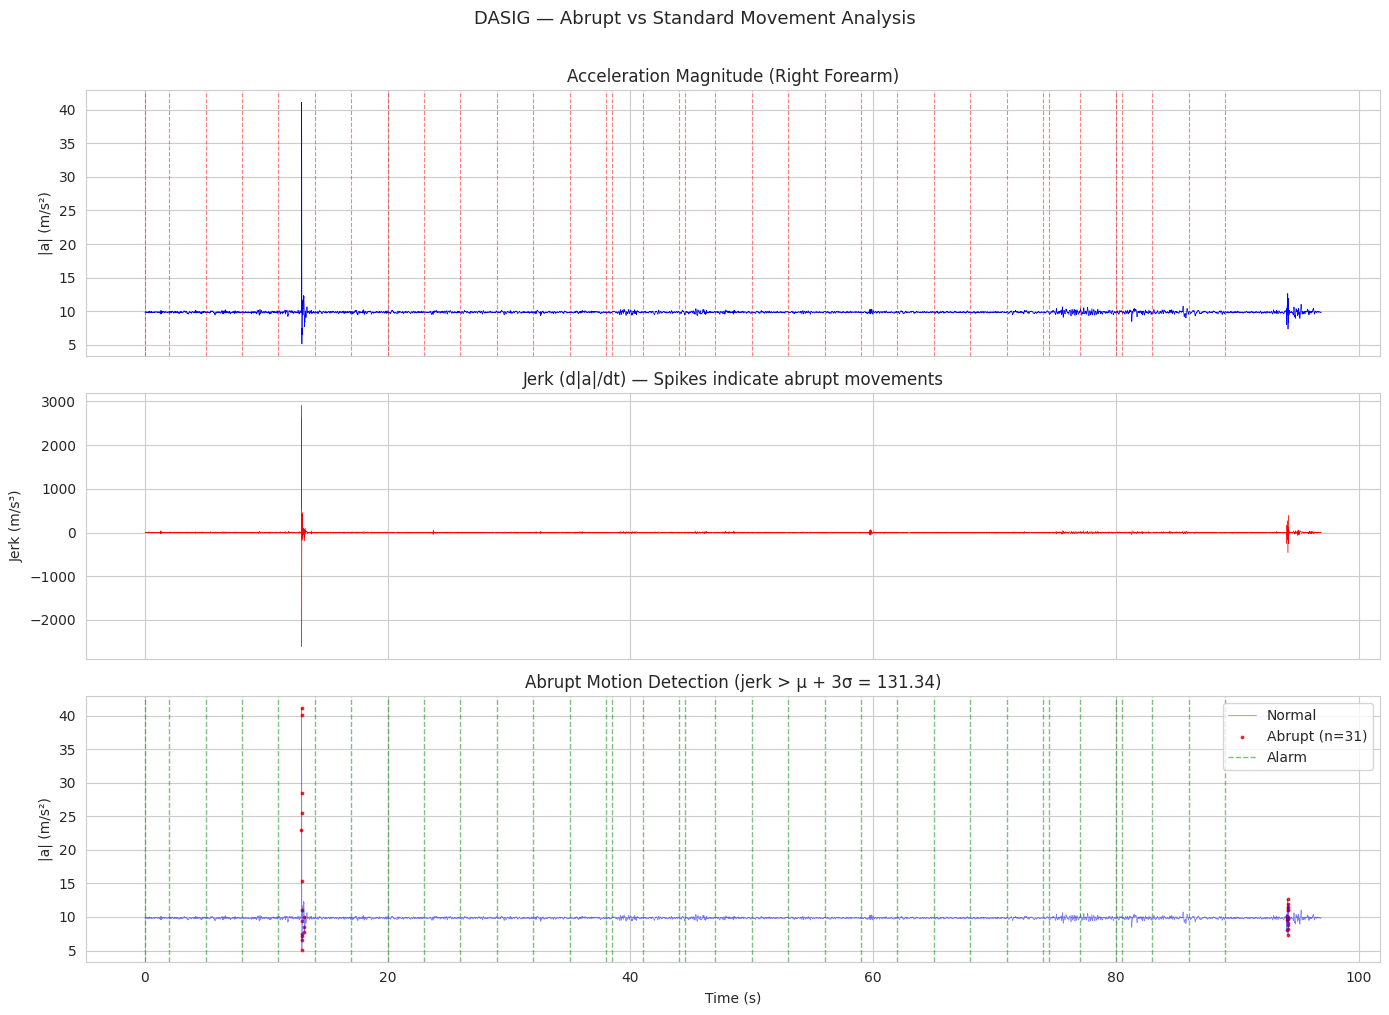

Abrupt motion threshold: 131.3442
Samples flagged as abrupt: 31 / 19384 (0.16%)


In [40]:
# ============================================================
# 4.2.2 — Detect and visualize abrupt vs standard gestures
# Key for: Safety layer (Axis A4, Layer 6)
# ============================================================

# Use Right Forearm accelerometer for abrupt motion detection
accel_cols = ['RF_Acc_X', 'RF_Acc_Y', 'RF_Acc_Z']

if mimu_sample is not None and all(c in mimu_sample.columns for c in accel_cols):
    time_vals = mimu_sample['Time_s'].values if 'Time_s' in mimu_sample.columns else np.arange(len(mimu_sample))
    
    # Compute acceleration magnitude
    acc_mag = np.sqrt(sum(mimu_sample[c].values**2 for c in accel_cols))
    
    # Compute jerk (derivative of acceleration) — indicator of abrupt motion
    dt = np.diff(time_vals)
    dt[dt == 0] = 1e-6  # avoid division by zero
    jerk = np.diff(acc_mag) / dt
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Acceleration magnitude
    ax1.plot(time_vals, acc_mag, linewidth=0.5, color='blue')
    ax1.set_ylabel('|a| (m/s²)')
    ax1.set_title('Acceleration Magnitude (Right Forearm)')
    
    # Overlay alarm timestamps if available
    if alarm_sample is not None and 'Time (s)' in alarm_sample.columns:
        for _, row in alarm_sample.iterrows():
            ax1.axvline(row['Time (s)'], color='red', alpha=0.5, linewidth=0.8, linestyle='--')
    
    # Jerk
    ax2.plot(time_vals[1:], jerk, linewidth=0.3, color='red')
    ax2.set_ylabel('Jerk (m/s³)')
    ax2.set_title('Jerk (d|a|/dt) — Spikes indicate abrupt movements')
    
    # Highlight abrupt regions (jerk > threshold)
    threshold = np.mean(np.abs(jerk)) + 3 * np.std(np.abs(jerk))
    abrupt_mask = np.abs(jerk) > threshold
    abrupt_indices = np.where(abrupt_mask)[0]
    
    ax3.plot(time_vals, acc_mag, linewidth=0.5, color='blue', alpha=0.5, label='Normal')
    if len(abrupt_indices) > 0:
        ax3.scatter(time_vals[abrupt_indices + 1], acc_mag[abrupt_indices + 1], 
                   c='red', s=3, alpha=0.8, label=f'Abrupt (n={len(abrupt_indices)})')
    
    # Overlay alarms
    if alarm_sample is not None and 'Time (s)' in alarm_sample.columns:
        for _, row in alarm_sample.iterrows():
            ax3.axvline(row['Time (s)'], color='green', alpha=0.5, linewidth=1, linestyle='--', label='Alarm')
        # Deduplicate legend entries
        handles, labels = ax3.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax3.legend(by_label.values(), by_label.keys())
    else:
        ax3.legend()
    
    ax3.set_ylabel('|a| (m/s²)')
    ax3.set_xlabel('Time (s)')
    ax3.set_title(f'Abrupt Motion Detection (jerk > μ + 3σ = {threshold:.2f})')
    
    plt.suptitle('DASIG — Abrupt vs Standard Movement Analysis', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    
    print(f"Abrupt motion threshold: {threshold:.4f}")
    print(f"Samples flagged as abrupt: {len(abrupt_indices)} / {len(jerk)} ({100*len(abrupt_indices)/len(jerk):.2f}%)")
else:
    print("MIMU data not available. Run the loading cells above.")

## 4.3 — Cross-Subject Analysis for Style Clustering

In [41]:
# ============================================================
# 4.3.1 — Compute summary features across all subjects
# This gives a preview of inter-subject variability for clustering
# ============================================================

def compute_mimu_features(mimu_path):
    """Compute summary features from a MIMU CSV file using load_mimu()."""
    df = load_mimu(mimu_path)
    if df is None or len(df) < 10:
        return None
    
    features = {}
    features['file'] = mimu_path.name
    features['subject'] = mimu_path.parent.name
    
    # Extract condition from filename (e.g., S01_FR_L_MIMU.csv → FR_L)
    name = mimu_path.stem  # e.g. S01_FR_L_MIMU
    parts = name.split('_')
    # Remove first (subject) and last (MIMU) parts
    features['condition'] = '_'.join(parts[1:-1]) if len(parts) > 2 else 'unknown'
    
    # Use named columns for Right Forearm accelerometer
    accel_cols = ['RF_Acc_X', 'RF_Acc_Y', 'RF_Acc_Z']
    gyro_cols = ['RF_Gyro_X', 'RF_Gyro_Y', 'RF_Gyro_Z']
    
    # Statistical features for accel channels
    for i, col in enumerate(accel_cols):
        if col in df.columns:
            features[f'acc_{i}_mean'] = df[col].mean()
            features[f'acc_{i}_std'] = df[col].std()
            features[f'acc_{i}_max'] = df[col].max()
            features[f'acc_{i}_min'] = df[col].min()
            features[f'acc_{i}_range'] = df[col].max() - df[col].min()
    
    # Statistical features for gyro channels
    for i, col in enumerate(gyro_cols):
        if col in df.columns:
            features[f'gyro_{i}_mean'] = df[col].mean()
            features[f'gyro_{i}_std'] = df[col].std()
            features[f'gyro_{i}_max'] = df[col].max()
    
    # Acceleration magnitude features
    if all(c in df.columns for c in accel_cols):
        acc_mag = np.sqrt(sum(df[c].values**2 for c in accel_cols))
        features['acc_mag_mean'] = np.mean(acc_mag)
        features['acc_mag_std'] = np.std(acc_mag)
        features['acc_mag_max'] = np.max(acc_mag)
        
        # Jerk features (derivative of acceleration magnitude)
        time_vals = df['Time_s'].values if 'Time_s' in df.columns else np.arange(len(df))
        dt = np.diff(time_vals)
        dt[dt == 0] = 1e-6
        jerk = np.diff(acc_mag) / dt
        features['jerk_mean'] = np.mean(np.abs(jerk))
        features['jerk_std'] = np.std(jerk)
        features['jerk_max'] = np.max(np.abs(jerk))
    
    features['n_samples'] = len(df)
    
    return features

if mimu_files:
    print(f"Computing features for {len(mimu_files)} MIMU recordings...")
    all_features = []
    for f in tqdm(mimu_files):
        try:
            feat = compute_mimu_features(f)
            if feat:
                all_features.append(feat)
        except Exception as e:
            pass  # Skip problematic files
    
    features_df = pd.DataFrame(all_features)
    print(f"\nComputed features for {len(features_df)} recordings")
    print(f"Subjects: {features_df['subject'].nunique()}")
    print(f"Conditions: {features_df['condition'].unique()}")
    display(features_df.head())
else:
    features_df = pd.DataFrame()
    print("No MIMU files found.")

Computing features for 180 MIMU recordings...


  0%|          | 0/180 [00:00<?, ?it/s]


Computed features for 179 recordings
Subjects: 60
Conditions: ['FR_L' 'FR_R' 'LA_L']


,file,subject,condition,acc_0_mean,acc_0_std,acc_0_max,acc_0_min,acc_0_range,acc_1_mean,acc_1_std,...,gyro_2_mean,gyro_2_std,gyro_2_max,acc_mag_mean,acc_mag_std,acc_mag_max,jerk_mean,jerk_std,jerk_max,n_samples
0,sub001_FR_L_MIMU.csv,sub001,FR_L,6.906706,0.431922,18.154135,-3.898711,22.052846,-6.023934,0.625866,...,0.003142,0.104612,1.802773,9.844273,0.409863,41.101883,6.049583,42.200749,2910.344681,19385
1,sub001_FR_R_MIMU.csv,sub001,FR_R,-1.951812,3.046155,15.359833,-13.425460,28.785293,-4.015564,2.042868,...,-0.002077,1.090107,5.013623,9.920209,1.352082,30.704096,34.871655,52.280539,1272.215588,19384
2,sub001_LA_L_MIMU.csv,sub001,LA_L,7.317101,0.821328,10.340349,-3.598430,13.938779,-5.819898,0.442446,...,0.015780,0.148654,1.922703,9.851887,0.203010,14.075792,5.693240,8.897491,138.912363,19384
3,sub002_FR_L_MIMU.csv,sub002,FR_L,-3.601383,0.277335,-2.710839,-5.870970,3.160131,-5.200494,0.199684,...,0.004336,0.057774,0.560708,9.723273,0.129401,11.743860,9.483583,16.891302,241.176862,19384
4,sub002_FR_R_MIMU.csv,sub002,FR_R,-2.604962,2.473528,11.374487,-16.696924,28.071411,-2.623936,2.306455,...,-0.012443,0.996772,4.265625,9.900110,1.350117,22.880206,28.551667,45.042575,1938.967424,19384


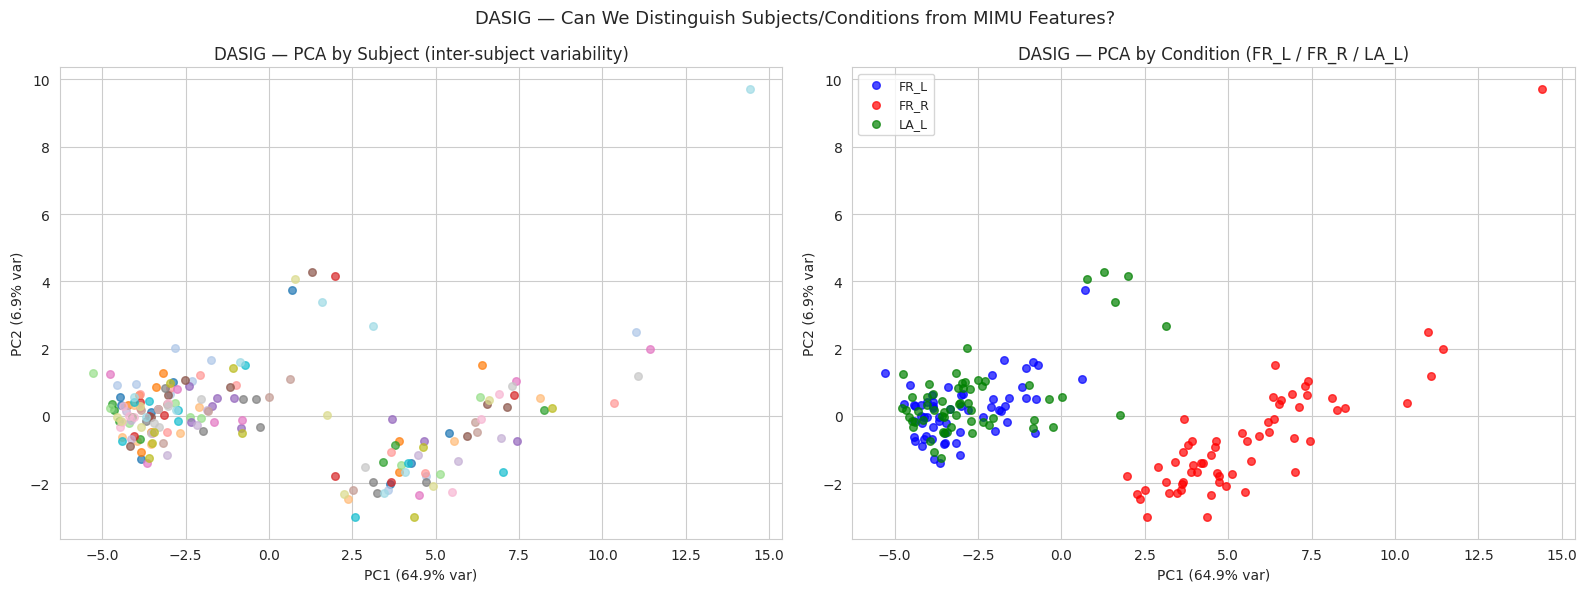


Explained variance: PC1=64.90%, PC2=6.92%
Total explained: 71.83%


In [42]:
# ============================================================
# 4.3.2 — PCA visualization of inter-subject variability
# Preview: Can we distinguish subjects by their motion patterns?
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

if mimu_files and len(features_df) > 5:
    # Select numeric feature columns
    feat_cols = [c for c in features_df.columns 
                 if c not in ['file', 'subject', 'condition', 'n_samples']]
    
    X = features_df[feat_cols].fillna(0).values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Color by subject
    subjects = features_df['subject'].values
    unique_subjects = np.unique(subjects)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_subjects)))
    subject_color_map = {s: colors[i % len(colors)] for i, s in enumerate(unique_subjects)}
    
    for subj in unique_subjects:
        mask = subjects == subj
        ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[subject_color_map[subj]], s=30, alpha=0.7, label=subj)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    ax1.set_title('DASIG — PCA by Subject (inter-subject variability)')
    # Show legend only if few subjects
    if len(unique_subjects) <= 15:
        ax1.legend(fontsize=6, ncol=2)
    
    # Color by condition
    conditions = features_df['condition'].values
    unique_conditions = np.unique(conditions)
    cond_colors = {'FR_L': 'blue', 'FR_R': 'red', 'LA_L': 'green'}
    
    for cond in unique_conditions:
        mask = conditions == cond
        color = cond_colors.get(cond, 'gray')
        ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=color, s=30, alpha=0.7, label=cond)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    ax2.set_title('DASIG — PCA by Condition (FR_L / FR_R / LA_L)')
    ax2.legend(fontsize=9)
    
    plt.suptitle('DASIG — Can We Distinguish Subjects/Conditions from MIMU Features?', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print(f"\nExplained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
    print(f"Total explained: {sum(pca.explained_variance_ratio_):.2%}")

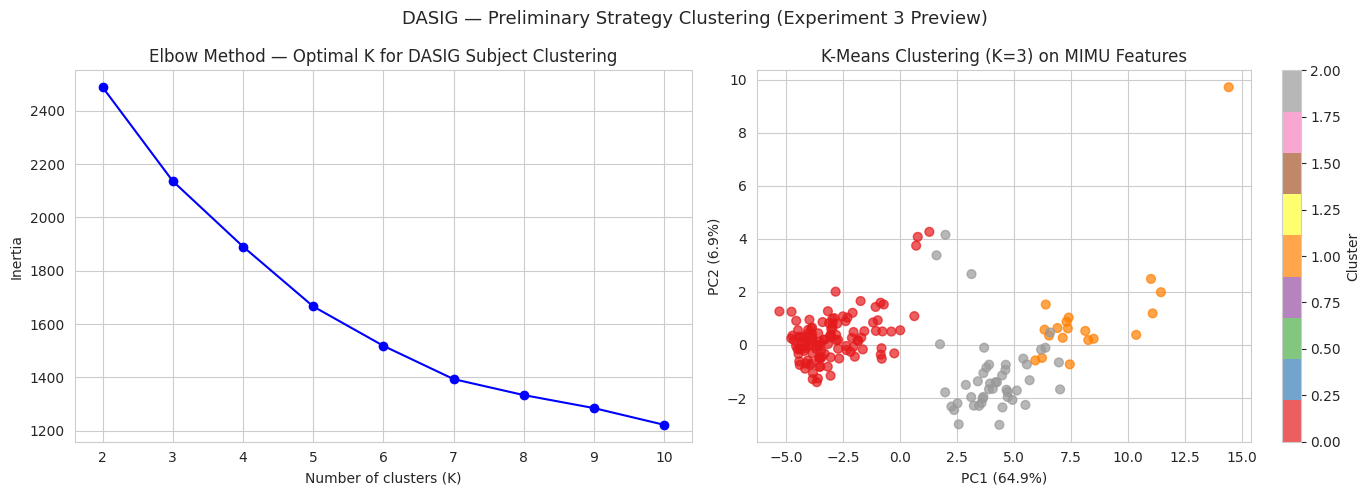


Cluster × Condition cross-tabulation:
condition  FR_L  FR_R  LA_L
cluster                    
0            60     0    55
1             0    19     0
2             0    41     4


In [43]:
# ============================================================
# 4.3.3 — Preliminary clustering (preview for Experiment 3)
# ============================================================

from sklearn.cluster import KMeans

if mimu_files and len(features_df) > 10:
    # Try K-Means with different K
    inertias = []
    K_range = range(2, min(11, len(features_df) // 2))
    
    for k in K_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow plot
    ax1.plot(list(K_range), inertias, 'bo-')
    ax1.set_xlabel('Number of clusters (K)')
    ax1.set_ylabel('Inertia')
    ax1.set_title('Elbow Method — Optimal K for DASIG Subject Clustering')
    
    # Best clustering visualization
    best_k = 3  # Reasonable default (matches 3 conditions)
    km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    
    scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', s=40, alpha=0.7)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax2.set_title(f'K-Means Clustering (K={best_k}) on MIMU Features')
    plt.colorbar(scatter, ax=ax2, label='Cluster')
    
    plt.suptitle('DASIG — Preliminary Strategy Clustering (Experiment 3 Preview)', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    # Cross-tab: clusters vs conditions
    features_df['cluster'] = labels
    print("\nCluster × Condition cross-tabulation:")
    print(pd.crosstab(features_df['cluster'], features_df['condition']))

## 4.4 — Compare Standard vs Abrupt Gestures Across Subjects

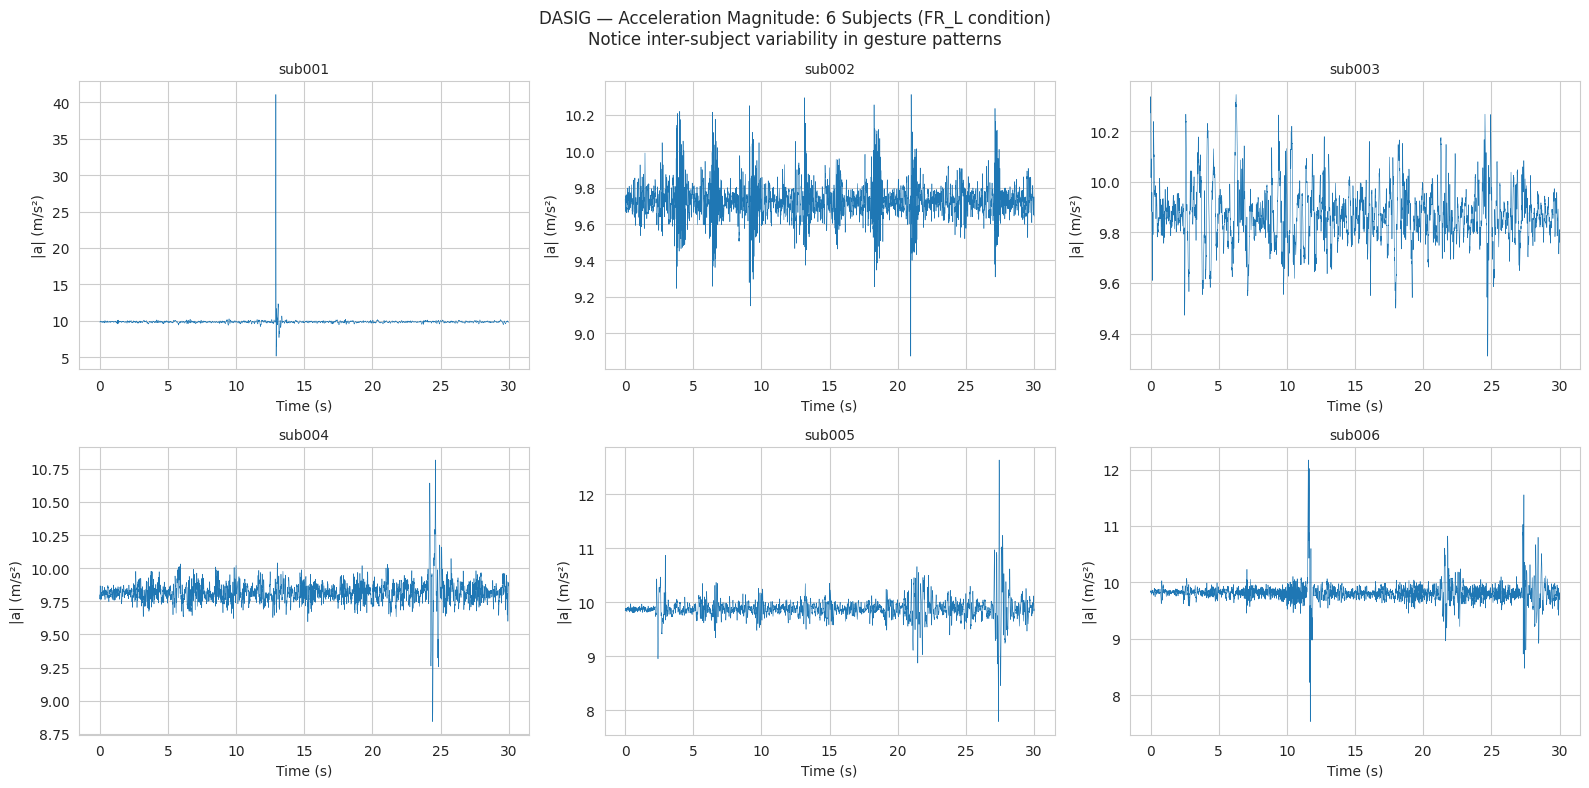

In [44]:
# ============================================================
# 4.4.1 — Overlay multiple subjects' acceleration for comparison
# This shows the inter-subject variability in gesture execution
# ============================================================

if mimu_files:
    # Pick one condition (e.g., FR_L) and compare first 6 subjects
    fr_l_files = [f for f in mimu_files if 'FR_L' in f.name][:6]
    
    if fr_l_files:
        fig, axes = plt.subplots(2, 3, figsize=(16, 8))
        axes = axes.flatten()
        
        accel_cols = ['RF_Acc_X', 'RF_Acc_Y', 'RF_Acc_Z']
        
        for i, f in enumerate(fr_l_files):
            df = load_mimu(f)
            if df is not None and all(c in df.columns for c in accel_cols):
                acc_mag = np.sqrt(sum(df[c].values**2 for c in accel_cols))
                time_vals = df['Time_s'].values if 'Time_s' in df.columns else np.arange(len(df))
                # Show first 30 seconds
                if 'Time_s' in df.columns:
                    mask = time_vals <= 30
                    axes[i].plot(time_vals[mask], acc_mag[mask], linewidth=0.4)
                    axes[i].set_xlabel('Time (s)')
                else:
                    n = min(3000, len(acc_mag))
                    axes[i].plot(acc_mag[:n], linewidth=0.4)
                axes[i].set_title(f.parent.name, fontsize=10)
                axes[i].set_ylabel('|a| (m/s²)')
        
        plt.suptitle('DASIG — Acceleration Magnitude: 6 Subjects (FR_L condition)\nNotice inter-subject variability in gesture patterns', 
                    fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("No FR_L files found among MIMU files.")
else:
    print("No MIMU files available.")

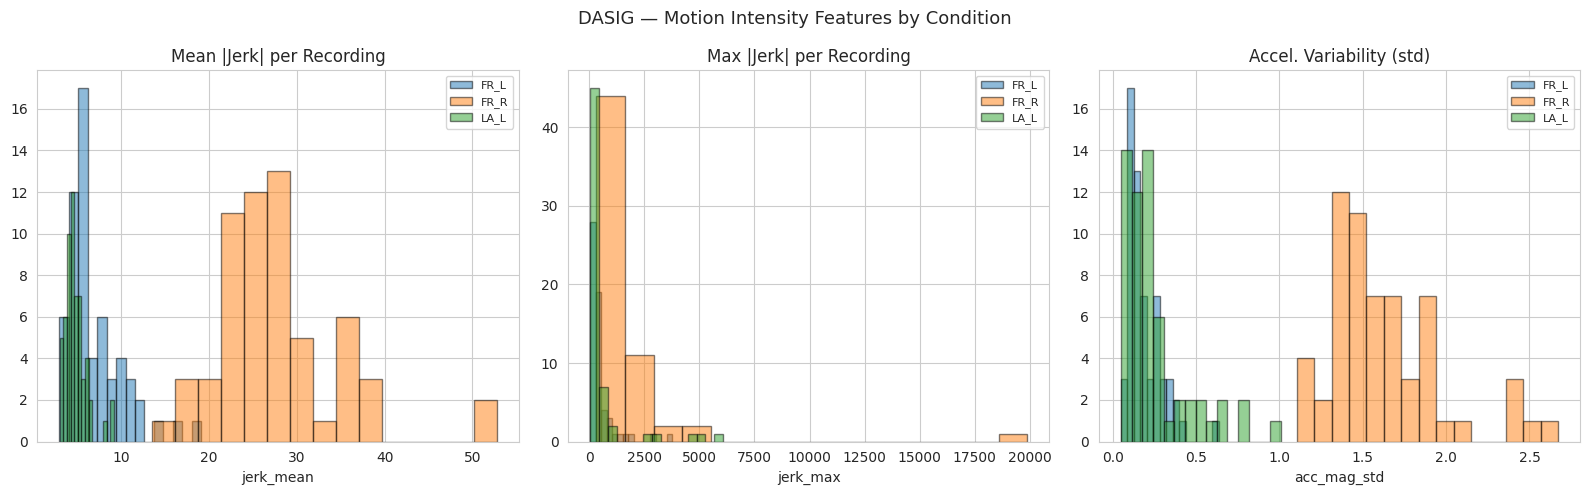

In [45]:
# ============================================================
# 4.4.2 — Feature distributions: Normal vs Abrupt motion
# Use jerk magnitude to separate calm vs abrupt segments
# ============================================================

if mimu_files and len(features_df) > 5:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['jerk_mean', 'jerk_max', 'acc_mag_std']
    titles = ['Mean |Jerk| per Recording', 'Max |Jerk| per Recording', 'Accel. Variability (std)']
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        if metric in features_df.columns:
            for cond in features_df['condition'].unique():
                mask = features_df['condition'] == cond
                axes[i].hist(features_df.loc[mask, metric], 
                           bins=15, alpha=0.5, label=cond, edgecolor='black')
            axes[i].set_title(title)
            axes[i].set_xlabel(metric)
            axes[i].legend(fontsize=8)
    
    plt.suptitle('DASIG — Motion Intensity Features by Condition', fontsize=13)
    plt.tight_layout()
    plt.show()

---
# Part 5 — Comparative Summary & Next Steps

## 5.1 — Dataset Comparison Table

In [46]:
# ============================================================
# Summary comparison of both datasets
# ============================================================

summary = {
    'Property': [
        'Subjects', 'Trials per subject', 'Total recordings',
        'EMG', 'IMU/MIMU', 'Gaze', 'Joystick', 'Robot joints',
        'Audio/Alarms', 'Video', 'Body/Hand/Face pose',
        'Standard gestures', 'Abrupt gestures',
        'Use for Style (A1)', 'Use for IRL (A2)', 
        'Use for BehavGen (A3)', 'Use for Safety (A4)'
    ],
    'HARMONIC': [
        '24', '~20', '~480',
        '✅ 8ch Myo', '✅ Myo IMU', '✅ Pupil Labs', '✅ Ada joystick', '✅ 6-DOF Kinova',
        '❌', '✅ Ego + 3rd person', '✅ OpenPose',
        '✅ (task sequences)', '❌',
        '⭐⭐⭐ (multi-modal per-subject)', '⭐⭐⭐ (commands+corrections+robot)',
        '⭐⭐⭐ (robot trajectories)', '⭐ (limited)'
    ],
    'DASIG': [
        '60', '3 conditions', '~180',
        '❌', '✅ 9ch MIMU', '❌', '❌', '❌',
        '✅ Arduino alarms', '✅ Example videos', '❌',
        '✅ Pick-and-place', '✅ Alarm-triggered',
        '⭐⭐ (60 subjects, high variability)', '⭐ (no robot data)',
        '⭐ (human trajectories only)', '⭐⭐⭐ (abrupt detection)'
    ]
}

summary_df = pd.DataFrame(summary)
display(summary_df.style.set_properties(**{'text-align': 'left'}))

,Property,HARMONIC,DASIG
0,Subjects,24,60
1,Trials per subject,~20,3 conditions
2,Total recordings,~480,~180
3,EMG,✅ 8ch Myo,❌
4,IMU/MIMU,✅ Myo IMU,✅ 9ch MIMU
5,Gaze,✅ Pupil Labs,❌
6,Joystick,✅ Ada joystick,❌
7,Robot joints,✅ 6-DOF Kinova,❌
8,Audio/Alarms,❌,✅ Arduino alarms
9,Video,✅ Ego + 3rd person,✅ Example videos


## 5.2 — Preprocessing Needs Identified

### HARMONIC
- [ ] **Timestamp alignment**: All CSVs have different sampling rates — need resampling to common rate (e.g., 50Hz)
- [ ] **EMG preprocessing**: Rectification → low-pass filter → normalization (MVC or z-score)
- [ ] **Gaze filtering**: Remove low-confidence samples, interpolate gaps
- [ ] **Episode segmentation**: Split continuous recordings into task episodes
- [ ] **Label extraction**: Extract implicit correction events from joystick/force data
- [ ] **Participant splits**: Define train/val/test splits respecting subject boundaries

### DASIG  
- [ ] **MIMU preprocessing**: Calibration offset removal, low-pass filtering (Butterworth)
- [ ] **Gesture segmentation**: Use alarm timestamps to define standard vs abrupt windows
- [ ] **Feature extraction**: Time-domain (mean, std, range, RMS, jerk) + frequency-domain (FFT peaks)
- [ ] **Windowing**: Sliding window (e.g., 200ms with 50% overlap) for classification
- [ ] **Subject-independent splits**: Leave-N-subjects-out cross-validation

## 5.3 — Mapping to Research Axes & Experiments

| Experiment | Primary Dataset | Secondary Dataset |
|-----------|----------------|-------------------|
| **Exp1** — IL comparison | HARMONIC (sequential sessions per subject) | LIBERO (when ready) |
| **Exp2** — IRL comparison | HARMONIC (joystick commands = demonstrations, corrections = rewards) | — |
| **Exp3** — Style modeling | DASIG (60 subjects, high variability) | HARMONIC (24 subjects, richer modalities) |
| **Exp4** — Behavior generation | HARMONIC (robot trajectories + style) | — |
| **Exp5** — Full system | HARMONIC (all modalities) | DASIG (safety layer) |
| **Exp6** — Longitudinal | Own data collection (Phase 1) | — |

In [47]:
# ============================================================
# Save processed features to disk for later use
# ============================================================

output_dir = DATA_DIR / 'processed'
output_dir.mkdir(exist_ok=True)

if mimu_files and len(features_df) > 0:
    features_df.to_csv(output_dir / 'dasig_features_summary.csv', index=False)
    print(f"Saved DASIG features: {output_dir / 'dasig_features_summary.csv'}")

if text_data_dirs and len(all_stats) > 0:
    stats_df.to_csv(output_dir / 'harmonic_trial_stats.csv', index=False)
    print(f"Saved HARMONIC stats: {output_dir / 'harmonic_trial_stats.csv'}")

print("\n✅ Exploration complete. Ready for Phase 2 — Algorithm Development.")

Saved DASIG features: /content/data/processed/dasig_features_summary.csv
Saved HARMONIC stats: /content/data/processed/harmonic_trial_stats.csv

✅ Exploration complete. Ready for Phase 2 — Algorithm Development.
